**PASO 0: IMPORTACIONES Y CONFIGURACIÓN GENERAL**

In [1]:
# PASO 0 · Importaciones y configuración general

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import statsmodels.api as sm
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

def make_onehot_encoder(drop="first"):
    """
    Helper para crear OneHotEncoder compatible con distintas versiones de sklearn.
    Devuelve densas (sparse_output=False o sparse=False según versión).
    """
    from sklearn.preprocessing import OneHotEncoder
    try:
        return OneHotEncoder(handle_unknown="ignore", drop=drop, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop=drop, sparse=False)

# CARGA DEL DATASET
DATA_PATH = "prosperLoanData.csv"  # ajustar si está en otra ruta
df = pd.read_csv(DATA_PATH, engine='python')
pd.options.display.max_columns = None

print("Dimensiones:", df.shape)
display(df.head(3))

print("\n--- info() ---")
df.info()

print("\n--- Descripción numérica ---")
display(df.describe().T)

print("\nDuplicados:", df.duplicated().sum())

print("\nTop 20 columnas con mayor % de NA")
na_pct = df.isna().mean().sort_values(ascending=False)
display((na_pct.head(20)*100).round(2).astype(str) + " %")


Dimensiones: (113937, 81)


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.158,0.138,NaN,NaN,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,640.0,659.0,2001-10-11 00:00:00,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,19141,9425,2007-09-12 00:00:00,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.0,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.092,0.082,0.0796,0.0249,0.0547,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,134815,10000,2014-03-03 00:00:00,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.275,0.240,NaN,NaN,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,480.0,499.0,2002-07-27 00:00:00,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,6466,3001,2007-01-17 00:00:00,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.0,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 1

,count,mean,std,min,25%,50%,75%,max
ListingNumber,113937.0,627885.692506,328076.236386,4.00000,400919.00000,600554.00000,892634.00000,1.255725e+06
Term,113937.0,40.830248,10.436212,12.00000,36.00000,36.00000,36.00000,6.000000e+01
BorrowerAPR,113912.0,0.218828,0.080364,0.00653,0.15629,0.20976,0.28381,5.122900e-01
BorrowerRate,113937.0,0.192764,0.074818,0.00000,0.13400,0.18400,0.25000,4.975000e-01
LenderYield,113937.0,0.182701,0.074516,-0.01000,0.12420,0.17300,0.24000,4.925000e-01
...,...,...,...,...,...,...,...,...
PercentFunded,113937.0,0.998584,0.017919,0.70000,1.00000,1.00000,1.00000,1.012500e+00
Recommendations,113937.0,0.048027,0.332353,0.00000,0.00000,0.00000,0.00000,3.900000e+01
InvestmentFromFriendsCount,113937.0,0.023460,0.232412,0.00000,0.00000,0.00000,0.00000,3.300000e+01
InvestmentFromFriendsAmount,113937.0,16.550751,294.545422,0.00000,0.00000,0.00000,0.00000,2.500000e+04



Duplicados: 0

Top 20 columnas con mayor % de NA


,0
GroupKey,88.29 %
LoanFirstDefaultedCycleNumber,85.12 %
ScorexChangeAtTimeOfListing,83.39 %
ProsperPaymentsOneMonthPlusLate,80.62 %
TotalProsperLoans,80.62 %
ProsperPaymentsLessThanOneMonthLate,80.62 %
ProsperPrincipalBorrowed,80.62 %
TotalProsperPaymentsBilled,80.62 %
OnTimeProsperPayments,80.62 %
ProsperPrincipalOutstanding,80.62 %


**DEFINICIÓN DE DEFAULT**

In [2]:
# PASO 1 · Construcción de la variable objetivo (default) con 3 escenarios

df["LoanStatus"] = df["LoanStatus"].astype(str).str.strip()

escenarios = {
    "A_minimo": {  # muy conservador
        "bad": {"Chargedoff", "Defaulted"},
        "good": {"Completed", "Current", "FinalPaymentInProgress"},
        "desc": "Default solo si Chargedoff o Defaulted."
    },
    "B_estandar": {  # estándar negocio: impago real o mora >60 días
        "bad": {"Chargedoff", "Defaulted",
                "Past Due (61-90 days)", "Past Due (91-120 days)", "Past Due (>120 days)"},
        "good": {"Completed", "Current", "FinalPaymentInProgress"},
        "desc": "Default si Chargedoff/Defaulted o mora >60 días."
    },
    "C_amplio": {  # incluye mora 31-60
        "bad": {"Chargedoff", "Defaulted",
                "Past Due (31-60 days)", "Past Due (61-90 days)",
                "Past Due (91-120 days)", "Past Due (>120 days)"},
        "good": {"Completed", "Current", "FinalPaymentInProgress"},
        "desc": "Default incluye mora >30 días."
    }
}

resumen_def = []
for nombre, cfg in escenarios.items():
    mask = df["LoanStatus"].isin(cfg["bad"].union(cfg["good"]))
    tmp = df.loc[mask].copy()
    tmp["default"] = np.where(tmp["LoanStatus"].isin(cfg["bad"]), 1, 0)
    resumen_def.append({
        "escenario": nombre,
        "descripcion": cfg["desc"],
        "muestras": tmp.shape[0],
        "tasa_default_%": round(tmp["default"].mean()*100, 2)
    })

resumen_def = pd.DataFrame(resumen_def).sort_values("tasa_default_%")
display(resumen_def)

# Elegimos el escenario B_estandar (criterio de negocio y regulatorio)
cfg = escenarios["B_estandar"]
mask_valida = df["LoanStatus"].isin(cfg["bad"].union(cfg["good"]))
df_model = df.loc[mask_valida].copy()
df_model["default"] = np.where(df_model["LoanStatus"].isin(cfg["bad"]), 1, 0)

print("Definición elegida: B_estandar →", cfg["desc"])
print("Tasa de default (%):", round(df_model["default"].mean()*100, 2))
print("Muestras finales:", df_model.shape[0])


,escenario,descripcion,muestras,tasa_default_%
0,A_minimo,Default solo si Chargedoff o Defaulted.,111865,15.21
1,B_estandar,Default si Chargedoff/Defaulted o mora >60 días.,112498,15.68
2,C_amplio,Default incluye mora >30 días.,112861,15.95


Definición elegida: B_estandar → Default si Chargedoff/Defaulted o mora >60 días.
Tasa de default (%): 15.68
Muestras finales: 112498


**PASO 2: LIMPIEZA GENERAL BASICA**

In [3]:
# PASO 2 · Limpieza y trazabilidad básica

n_inicial = df_model.shape[0]

# Duplicados
dup_count = df_model.duplicated().sum()
df_model = df_model.drop_duplicates()
print(f"Duplicados eliminados: {dup_count}")

# Infinitos → NaN
num_df = df_model.select_dtypes(include=[np.number])
n_inf = np.isinf(num_df).sum().sum()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Infinitos convertidos a NaN: {int(n_inf)}")

# Resumen NA (%)
na_pct = (df_model.isna().mean()*100).sort_values(ascending=False)
print("\nTOP columnas con NA (%):")
display(na_pct.head(20).round(2))

# Regla general: columnas con >40 % NA se excluyen del modelado
NA_THRESHOLD = 40.0
cols_na40 = na_pct[na_pct > NA_THRESHOLD].index.tolist()
print("\nColumnas excluidas por tener >40% NA:")
print(cols_na40)

df_model = df_model.drop(columns=cols_na40, errors="ignore")

print("\nDimensiones tras limpieza básica:", df_model.shape)


Duplicados eliminados: 0
Infinitos convertidos a NaN: 0

TOP columnas con NA (%):


,0
GroupKey,88.17
LoanFirstDefaultedCycleNumber,84.93
ScorexChangeAtTimeOfListing,83.52
ProsperPrincipalBorrowed,80.73
TotalProsperLoans,80.73
TotalProsperPaymentsBilled,80.73
OnTimeProsperPayments,80.73
ProsperPaymentsOneMonthPlusLate,80.73
ProsperPrincipalOutstanding,80.73
ProsperPaymentsLessThanOneMonthLate,80.73



Columnas excluidas por tener >40% NA:
['GroupKey', 'LoanFirstDefaultedCycleNumber', 'ScorexChangeAtTimeOfListing', 'ProsperPrincipalBorrowed', 'TotalProsperLoans', 'TotalProsperPaymentsBilled', 'OnTimeProsperPayments', 'ProsperPaymentsOneMonthPlusLate', 'ProsperPrincipalOutstanding', 'ProsperPaymentsLessThanOneMonthLate', 'CreditGrade', 'ClosedDate']

Dimensiones tras limpieza básica: (112498, 70)


**PASO 2B: TRATAMIENTO DETALLADO**

In [4]:
cols_to_drop = [
    # Identificadores
    "ListingKey", "ListingNumber", "LoanKey", "MemberKey", "GroupKey",

    # Resultado / fuga de información
    "LoanStatus", "ClosedDate", "LoanCurrentDaysDelinquent",
    "LoanFirstDefaultedCycleNumber", "LoanMonthsSinceOrigination",
    "LP_CustomerPayments", "LP_CustomerPrincipalPayments",
    "LP_InterestandFees", "LP_ServiceFees", "LP_CollectionFees",
    "LP_GrossPrincipalLoss", "LP_NetPrincipalLoss",
    "LP_NonPrincipalRecoverypayments",

    # Ratings internos de Prosper / derivados
    "CreditGrade", "ProsperRating (numeric)", "ProsperRating (Alpha)",
    "EstimatedEffectiveYield", "EstimatedLoss", "EstimatedReturn",

    # Histórico Prosper muy incompleto
    "TotalProsperLoans", "TotalProsperPaymentsBilled", "OnTimeProsperPayments",
    "ProsperPaymentsLessThanOneMonthLate", "ProsperPaymentsOneMonthPlusLate",
    "ProsperPrincipalBorrowed", "ProsperPrincipalOutstanding",
    "ScorexChangeAtTimeOfListing",

    # Fechas (podria transformarlas?)
    "ListingCreationDate", "DateCreditPulled", "FirstRecordedCreditLine",
    "LoanOriginationDate", "LoanOriginationQuarter"
]

df_model = df_model.drop(columns=cols_to_drop, errors="ignore")
print("Columnas eliminadas:", [c for c in cols_to_drop if c in df_model.columns])
print("Número de columnas tras el drop:", df_model.shape[1])


# 2) FICOScore = media del rango de crédito
if "CreditScoreRangeLower" in df_model.columns and "CreditScoreRangeUpper" in df_model.columns:
    df_model["FICOScore"] = df_model[["CreditScoreRangeLower", "CreditScoreRangeUpper"]].mean(axis=1)
    print("→ Columna FICOScore creada.")

# 3) Occupation → variables dicotómicas simples
if "Occupation" in df_model.columns:
    df_model["Occupation_missing"] = df_model["Occupation"].isna().astype(int)
    top_occs = df_model["Occupation"].value_counts().head(5).index
    df_model["Occupation_top5"] = df_model["Occupation"].isin(top_occs).astype(int)
    df_model = df_model.drop(columns=["Occupation"])
    print("→ Occupation transformada en Occupation_missing y Occupation_top5.")

# 4) IsBorrowerHomeowner (0/1, NA→0)
if "IsBorrowerHomeowner" in df_model.columns:
    df_model["IsBorrowerHomeowner"] = df_model["IsBorrowerHomeowner"].fillna(0).astype(int)
    print("→ IsBorrowerHomeowner normalizada a 0/1 (NA→0).")

# 5) IncomeVerifiable → 0/1
if "IncomeVerifiable" in df_model.columns:
    df_model["IncomeVerifiable"] = df_model["IncomeVerifiable"].map(
        {True:1, False:0, "Yes":1, "No":0}
    ).fillna(0).astype(int)
    print("→ IncomeVerifiable transformada a 0/1.")

# 6) IncomeRange → ordinal, -1 para desconocido
if "IncomeRange" in df_model.columns:
    income_map = {
        "Not displayed": -1,
        "Not employed": -1,
        "$0": 0,
        "$1-24,999": 1,
        "$25,000-49,999": 2,
        "$50,000-74,999": 3,
        "$75,000-99,999": 4,
        "$100,000+": 5
    }
    df_model["IncomeRange_num"] = df_model["IncomeRange"].map(income_map).fillna(-1).astype(int)
    df_model = df_model.drop(columns=["IncomeRange"])
    print("→ IncomeRange transformada en IncomeRange_num (ordinal, -1=desconocido).")

# 7) BorrowerState → high_risk vs resto + missing flag
if "BorrowerState" in df_model.columns:
    state_default_rate = df_model.groupby("BorrowerState")["default"].mean()
    umbral = state_default_rate.median()
    high_risk_states = state_default_rate[state_default_rate > umbral].index
    df_model["State_high_risk"] = df_model["BorrowerState"].isin(high_risk_states).astype(int)
    df_model["State_missing"]   = df_model["BorrowerState"].isna().astype(int)
    df_model = df_model.drop(columns=["BorrowerState"])
    print("→ BorrowerState transformada en State_high_risk y State_missing.")

# 8) ListingCategory (numeric) → 7 dummies + "other"
listing_col = None
for col in df_model.columns:
    if "ListingCategory" in col and "numeric" in col:
        listing_col = col
        break

if listing_col is not None:
    top_cats = df_model[listing_col].value_counts().head(7).index
    for cat in top_cats:
        df_model[f"ListingCat_{int(cat)}"] = (df_model[listing_col] == cat).astype(int)
    df_model["ListingCat_other"] = (~df_model[listing_col].isin(top_cats)).astype(int)
    df_model = df_model.drop(columns=[listing_col])
    print(f"→ {listing_col} transformada en dummies ListingCat_* (8 categorías).")

# 9) PercentFunded → 0 → media
if "PercentFunded" in df_model.columns:
    mask_pos = df_model["PercentFunded"] > 0
    if mask_pos.any():
        mean_pf = df_model.loc[mask_pos, "PercentFunded"].mean()
        df_model.loc[df_model["PercentFunded"] == 0, "PercentFunded"] = mean_pf
        print("→ PercentFunded: 0 reemplazados por la media de los valores >0.")

# 10) Recommendations → NA → 0
if "Recommendations" in df_model.columns:
    df_model["Recommendations"] = df_model["Recommendations"].fillna(0)
    print("→ Recommendations: NA → 0.")

# 11) Investors → NA → 1
if "Investors" in df_model.columns:
    df_model["Investors"] = df_model["Investors"].fillna(1)
    print("→ Investors: NA → 1.")

# 12) Rellenar NA restantes numéricos con 0 (regla global)
num_cols_all = df_model.select_dtypes(include=[np.number]).columns.tolist()
df_model[num_cols_all] = df_model[num_cols_all].fillna(0)

print("\nDimensiones finales de df_model tras tratamiento detallado:", df_model.shape)


Columnas eliminadas: []
Número de columnas tras el drop: 45
→ Columna FICOScore creada.
→ Occupation transformada en Occupation_missing y Occupation_top5.
→ IsBorrowerHomeowner normalizada a 0/1 (NA→0).
→ IncomeVerifiable transformada a 0/1.
→ IncomeRange transformada en IncomeRange_num (ordinal, -1=desconocido).
→ BorrowerState transformada en State_high_risk y State_missing.
→ ListingCategory (numeric) transformada en dummies ListingCat_* (8 categorías).
→ PercentFunded: 0 reemplazados por la media de los valores >0.
→ Recommendations: NA → 0.
→ Investors: NA → 1.

Dimensiones finales de df_model tras tratamiento detallado: (112498, 55)


**EXTRA 2C?: Winsorización, transformación log y eliminar columnas constantes**

In [5]:
# EXTENSIÓN PASO 2B · Limpieza avanzada

# 1) Winsorización al 1% y 99% en variables financieras clave
cols_winsor = [
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "RevolvingCreditBalance",
    "LoanOriginalAmount"
]

cols_winsor = [c for c in cols_winsor if c in df_model.columns]

print("\nAplicando winsorización (1% - 99%) a:", cols_winsor)
for col in cols_winsor:
    q1 = df_model[col].quantile(0.01)
    q99 = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=q1, upper=q99)

# 2) Transformaciones logarítmicas (log1p para evitar problemas con 0)
#    Creamos NUEVAS variables: no sustituimos a las originales
if "StatedMonthlyIncome" in df_model.columns:
    df_model["log_StatedMonthlyIncome"] = np.log1p(df_model["StatedMonthlyIncome"])
    print("→ Creada variable log_StatedMonthlyIncome")

if "LoanOriginalAmount" in df_model.columns:
    df_model["log_LoanOriginalAmount"] = np.log1p(df_model["LoanOriginalAmount"])
    print("→ Creada variable log_LoanOriginalAmount")

if "RevolvingCreditBalance" in df_model.columns:
    df_model["log_RevolvingCreditBalance"] = np.log1p(df_model["RevolvingCreditBalance"])
    print("→ Creada variable log_RevolvingCreditBalance")

# 3) Eliminación de columnas casi constantes (≥ 99% del mismo valor)
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

near_constant_cols = []
threshold = 0.99

for col in numeric_cols:
    # No queremos tocar la variable objetivo
    if col == "default":
        continue
    # Distribución de frecuencias normalizada
    freqs = df_model[col].value_counts(normalize=True, dropna=False)
    if not freqs.empty and freqs.iloc[0] >= threshold:
        near_constant_cols.append(col)

if near_constant_cols:
    print("\nColumnas casi constantes eliminadas (>= 99% mismo valor):")
    print(near_constant_cols)
    df_model = df_model.drop(columns=near_constant_cols)
else:
    print("\nNo se detectaron columnas casi constantes (>= 99% mismo valor).")

print("\nDimensiones de df_model tras limpieza avanzada:", df_model.shape)



Aplicando winsorización (1% - 99%) a: ['StatedMonthlyIncome', 'DebtToIncomeRatio', 'RevolvingCreditBalance', 'LoanOriginalAmount']
→ Creada variable log_StatedMonthlyIncome
→ Creada variable log_LoanOriginalAmount
→ Creada variable log_RevolvingCreditBalance

Columnas casi constantes eliminadas (>= 99% mismo valor):
['PercentFunded']

Dimensiones de df_model tras limpieza avanzada: (112498, 57)


**PASO 3: DEFINICIÓN DE X,y (variables explicativas y target)**

In [6]:
# PASO 3 · Definición de X (features) e y (target)

cols_excluir_modelo = [
    "LoanStatus",   # usada para crear default
    "default"       # variable objetivo
]

feature_cols = [c for c in df_model.columns if c not in cols_excluir_modelo]

X = df_model[feature_cols].copy()
y = df_model["default"].copy()

print("Número de variables explicativas tras tratamiento:", len(feature_cols))
print("Ejemplo de variables:", feature_cols[:20])


Número de variables explicativas tras tratamiento: 56
Ejemplo de variables: ['Term', 'BorrowerAPR', 'BorrowerRate', 'LenderYield', 'ProsperScore', 'EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner', 'CurrentlyInGroup', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts', 'OpenRevolvingMonthlyPayment', 'InquiriesLast6Months', 'TotalInquiries', 'CurrentDelinquencies', 'AmountDelinquent']


**PASO 4: ANÁLISIS EXPLORATORIO RÁPIDO (Histogramas numéricos)**

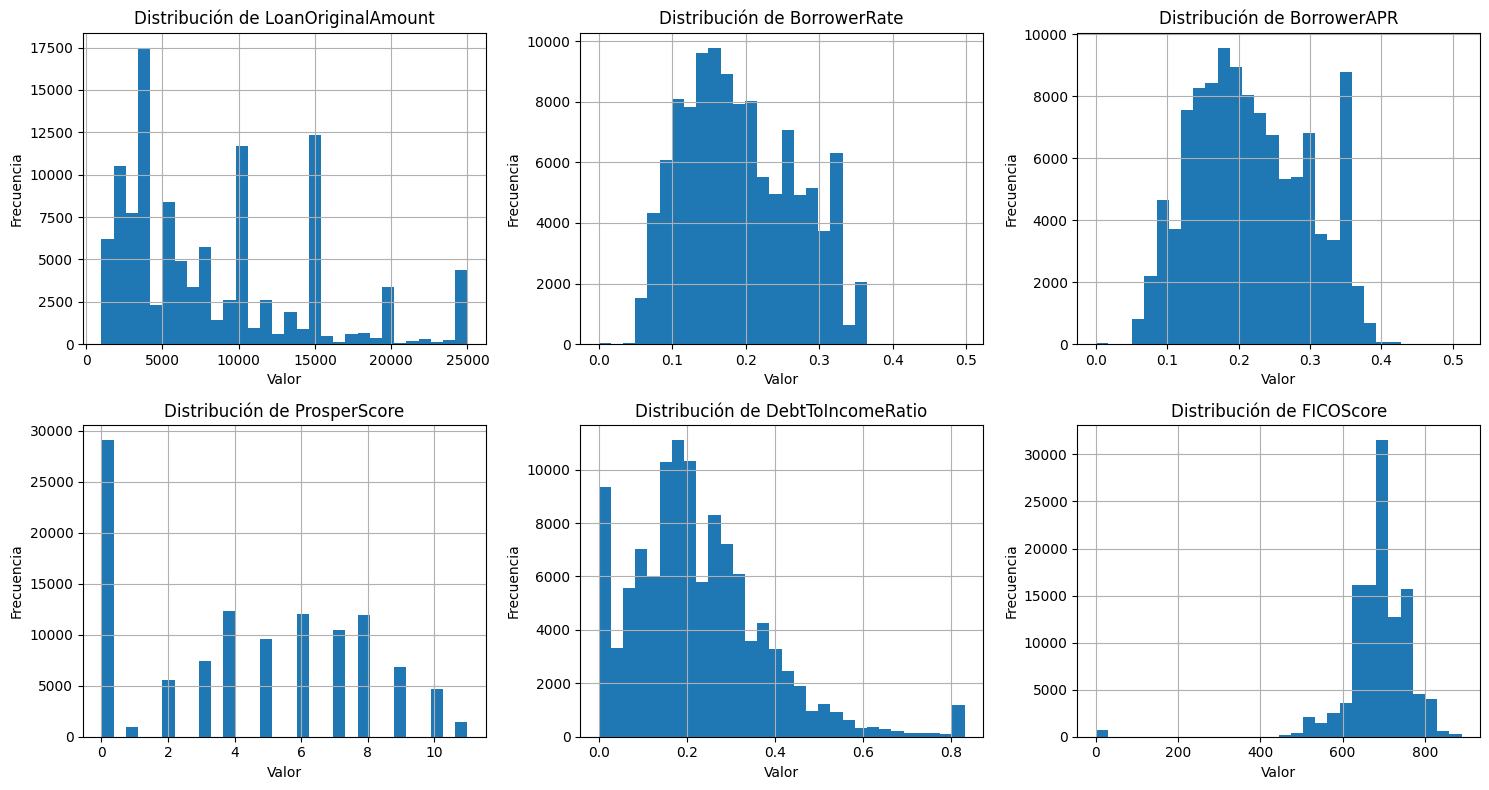

In [7]:
# PASO 4 · Histogramas de variables numéricas seleccionadas (EDA básico)
cols = [
    "LoanOriginalAmount",
    "BorrowerRate",
    "BorrowerAPR",
    "ProsperScore",
    "DebtToIncomeRatio",
    "FICOScore"
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(cols):
    X[col].dropna().hist(bins=30, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

fig.tight_layout()

fig.savefig("histogramas_variables_numericas.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()



In [8]:
from google.colab import files
files.download("histogramas_variables_numericas.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
df_model.columns.tolist()

['Term',
 'BorrowerAPR',
 'BorrowerRate',
 'LenderYield',
 'ProsperScore',
 'EmploymentStatus',
 'EmploymentStatusDuration',
 'IsBorrowerHomeowner',
 'CurrentlyInGroup',
 'CreditScoreRangeLower',
 'CreditScoreRangeUpper',
 'CurrentCreditLines',
 'OpenCreditLines',
 'TotalCreditLinespast7years',
 'OpenRevolvingAccounts',
 'OpenRevolvingMonthlyPayment',
 'InquiriesLast6Months',
 'TotalInquiries',
 'CurrentDelinquencies',
 'AmountDelinquent',
 'DelinquenciesLast7Years',
 'PublicRecordsLast10Years',
 'PublicRecordsLast12Months',
 'RevolvingCreditBalance',
 'BankcardUtilization',
 'AvailableBankcardCredit',
 'TotalTrades',
 'TradesNeverDelinquent (percentage)',
 'TradesOpenedLast6Months',
 'DebtToIncomeRatio',
 'IncomeVerifiable',
 'StatedMonthlyIncome',
 'LoanNumber',
 'LoanOriginalAmount',
 'MonthlyLoanPayment',
 'Recommendations',
 'InvestmentFromFriendsCount',
 'InvestmentFromFriendsAmount',
 'Investors',
 'default',
 'FICOScore',
 'Occupation_missing',
 'Occupation_top5',
 'IncomeRange

**Hacer grafico correlación todas las variables**

In [10]:
df_model.to_csv("df_model_limpio.csv", index=False)


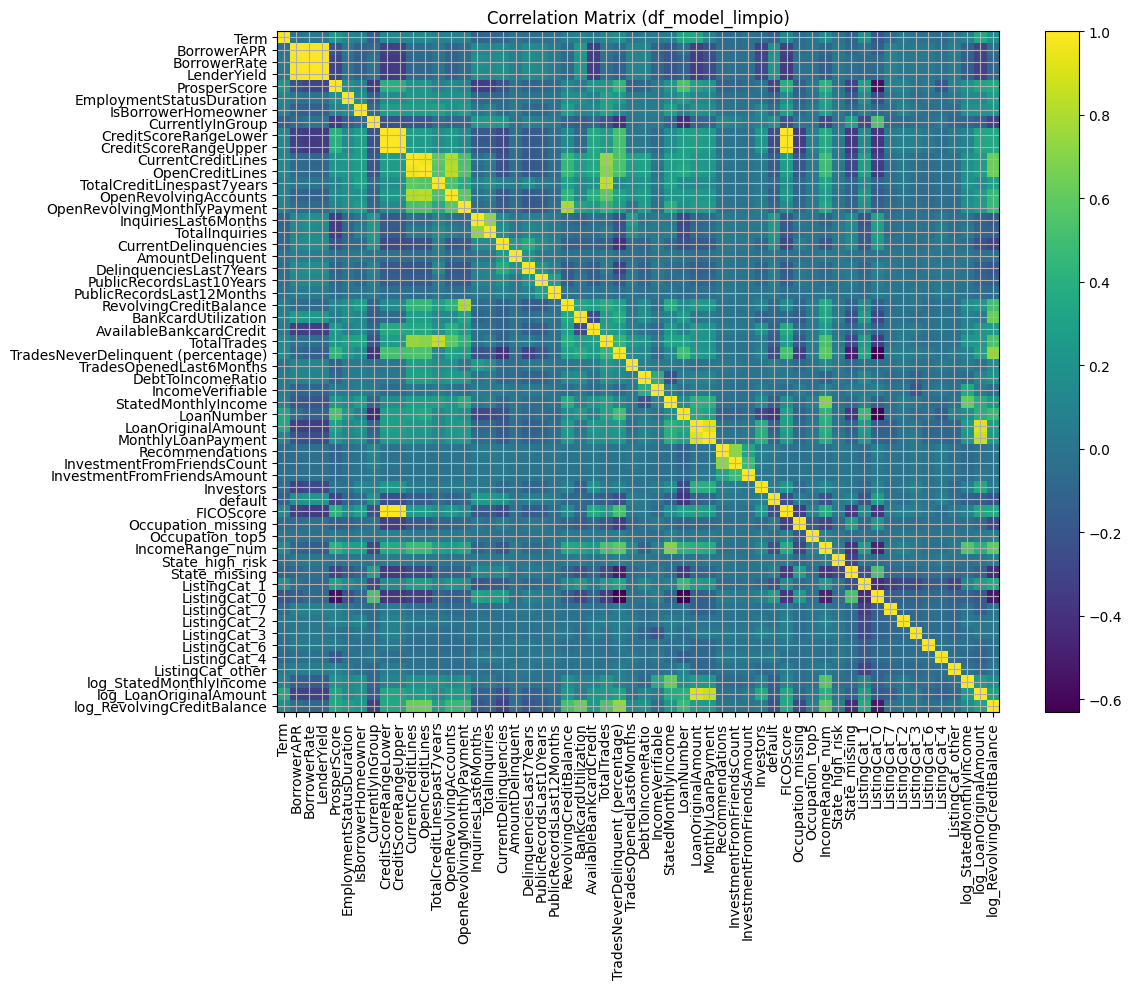

/tmp/ipykernel_19559/507185594.py:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance, method="ward")


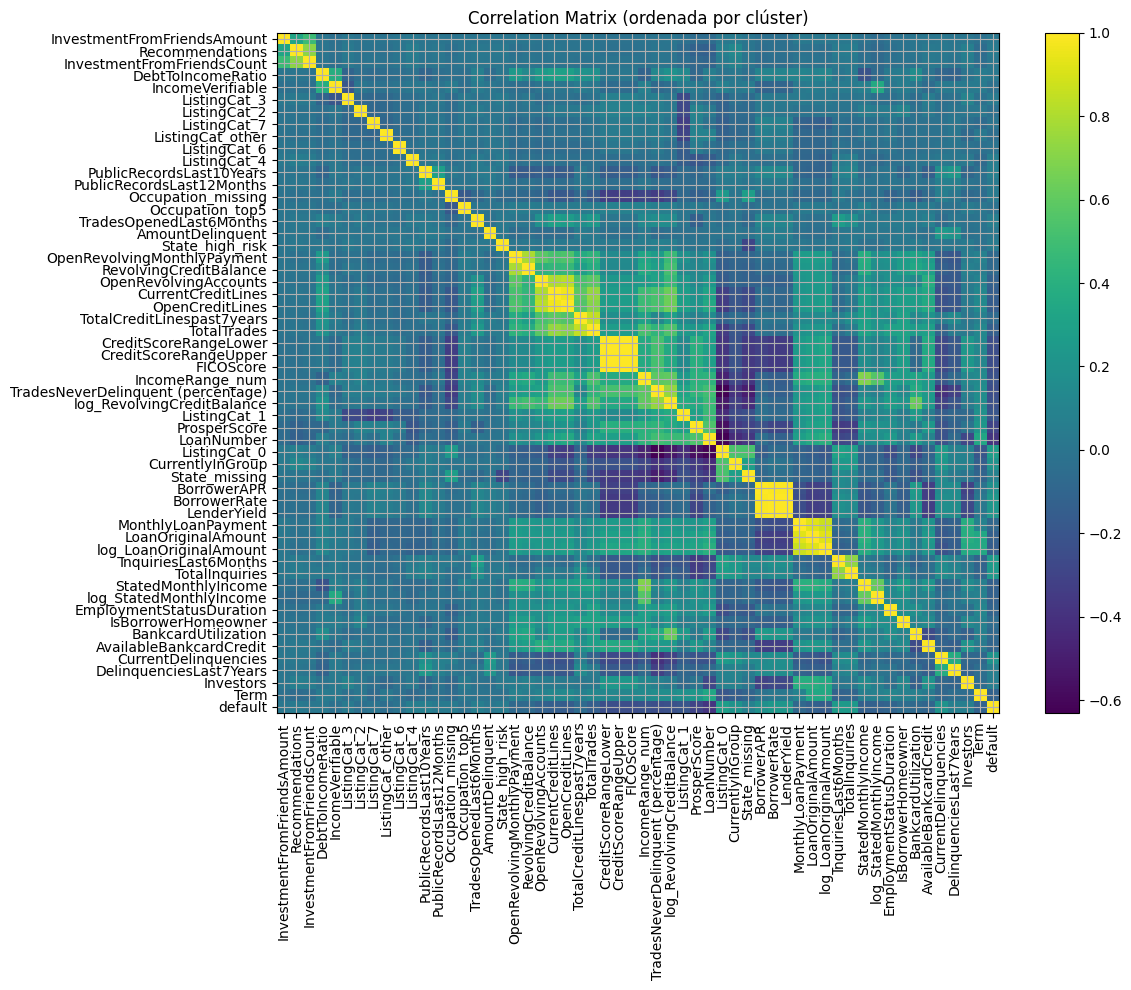


Pares de variables con correlación fuerte (|r| >=  0.7 ):
                                    var1                        var2  corr_abs
488                CreditScoreRangeUpper                   FICOScore  0.999979
442                CreditScoreRangeLower                   FICOScore  0.999978
412                CreditScoreRangeLower       CreditScoreRangeUpper  0.999914
109                         BorrowerRate                 LenderYield  0.999201
55                           BorrowerAPR                BorrowerRate  0.989525
56                           BorrowerAPR                 LenderYield  0.989030
505                   CurrentCreditLines             OpenCreditLines  0.967992
1264                  LoanOriginalAmount          MonthlyLoanPayment  0.929328
1285                  LoanOriginalAmount      log_LoanOriginalAmount  0.923966
1307                  MonthlyLoanPayment      log_LoanOriginalAmount  0.868880
606           TotalCreditLinespast7years                 TotalTrades  0.

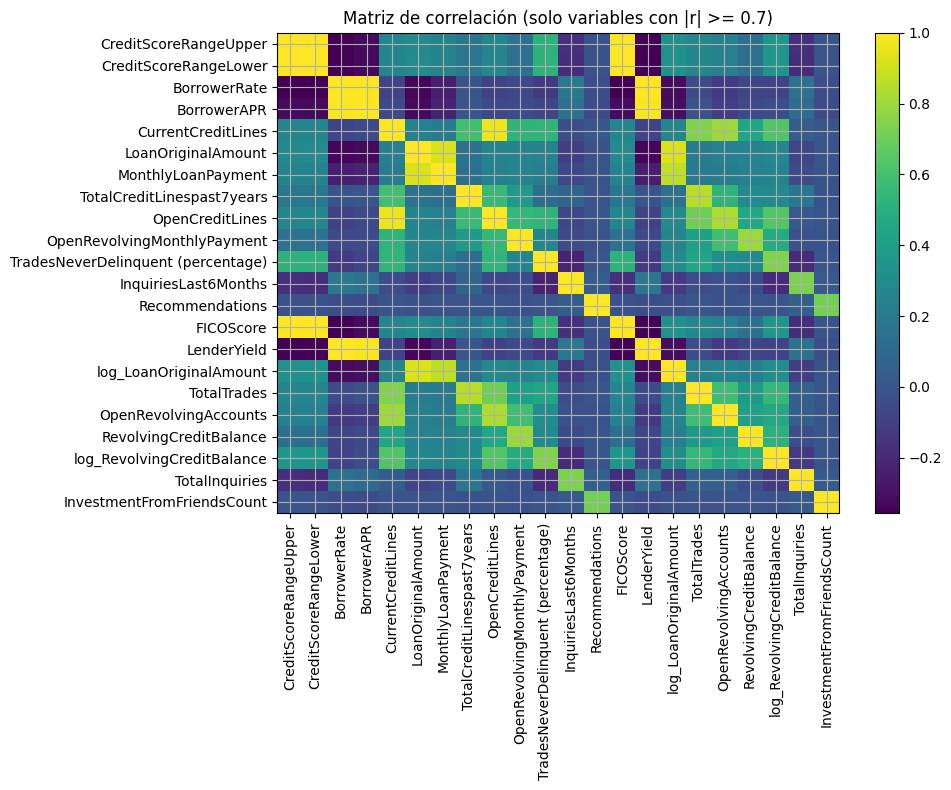

In [11]:
# MATRICES DE CORRELACIÓN (NORMAL, CLÚSTER, FUERTES)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# 0. Cargar tu dataset limpio
df = pd.read_csv("df_model_limpio.csv")

# 1. Calcular matriz de correlación sólo con variables numéricas
corr = df.corr(numeric_only=True)

# 1) MATRIZ DE CORRELACIÓN NORMAL
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix (df_model_limpio)")
plt.tight_layout()
plt.show()

# 2) MATRIZ ORDENADA POR CLÚSTER

# Distancia basada en la correlación absoluta
# (cuanto más alta la correlación, más cerca en el clúster)
distance = 1 - corr.abs()

# Enlace jerárquico
Z = linkage(distance, method="ward")

# Orden de las variables según el dendrograma
cluster_order = leaves_list(Z)

# Reordenar la matriz de correlación
corr_clustered = corr.iloc[cluster_order, cluster_order]

plt.figure(figsize=(12, 10))
plt.imshow(corr_clustered, aspect='auto')
plt.xticks(range(len(corr_clustered.columns)),
           corr_clustered.columns, rotation=90)
plt.yticks(range(len(corr_clustered.columns)),
           corr_clustered.columns)
plt.colorbar()
plt.title("Correlation Matrix (ordenada por clúster)")
plt.tight_layout()
plt.show()

# 3) MATRIZ SÓLO CON CORRELACIONES FUERTES

# Umbral de correlación fuerte
threshold = 0.7  # puedes cambiarlo a 0.6, 0.8, etc.

# Correlación absoluta
corr_abs = corr.abs()

# Nos quedamos solo con la parte superior de la matriz (sin duplicar pares)
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
strong_pairs = corr_abs.where(mask).stack().reset_index()
strong_pairs.columns = ["var1", "var2", "corr_abs"]

# Filtrar por correlaciones fuertes
strong_pairs = strong_pairs[strong_pairs["corr_abs"] >= threshold] \
                             .sort_values("corr_abs", ascending=False)

print("\nPares de variables con correlación fuerte (|r| >= ", threshold, "):")
print(strong_pairs)

latex_corr = strong_pairs.to_latex(
    index=False,
    caption="Pares de variables con correlación fuerte ($|r| \\geq 0.7$)",
    label="tab:corr_fuertes",
    float_format="%.6f"
)

print(latex_corr)

# Opcional: matriz reducida solo con las variables que tienen correlaciones fuertes
strong_vars = pd.unique(strong_pairs[["var1", "var2"]].values.ravel("K"))

if len(strong_vars) > 0:
    corr_strong = corr.loc[strong_vars, strong_vars]

    plt.figure(figsize=(10, 8))
    plt.imshow(corr_strong, aspect='auto')
    plt.xticks(range(len(corr_strong.columns)),
               corr_strong.columns, rotation=90)
    plt.yticks(range(len(corr_strong.columns)),
               corr_strong.columns)
    plt.colorbar()
    plt.title(f"Matriz de correlación (solo variables con |r| >= {threshold})")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se encontraron pares con correlación por encima del umbral.")



In [12]:
# PASO 4.5 · Eliminación de variables numéricas altamente correlacionadas (simplificación del modelo)

import numpy as np
import pandas as pd

def drop_correlated_features(
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float = 0.7,
    forced_keep_rules: list | None = None,
    prefer_keep: dict | None = None
):
    """
    Detecta variables numéricas altamente correlacionadas (|r| >= threshold)
    y elimina redundancias, dejando 1 variable por grupo.
    - forced_keep_rules: lista de reglas tipo {"set": {...}, "keep": "..."}
    - prefer_keep: dict {variable: prioridad_int} (más alto => más preferida)
    """
    X_new = X.copy()
    y_vec = y.copy()

    num_cols = X_new.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) < 2:
        print("No hay suficientes columnas numéricas para analizar correlación.")
        return X_new, pd.DataFrame()

    corr = X_new[num_cols].corr().abs()

    # pares fuertes
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ["var1", "var2", "corr_abs"]
    pairs = pairs[pairs["corr_abs"] >= threshold].sort_values("corr_abs", ascending=False)

    if pairs.empty:
        print(f"No se encontraron pares con |r| >= {threshold}. No se elimina nada.")
        return X_new, pd.DataFrame()

    # construir grupos conectados (componentes conexas)
    parent = {}
    def find(a):
        parent.setdefault(a, a)
        if parent[a] != a:
            parent[a] = find(parent[a])
        return parent[a]
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for _, r in pairs.iterrows():
        union(r["var1"], r["var2"])

    groups = {}
    for v in set(pairs["var1"]).union(set(pairs["var2"])):
        root = find(v)
        groups.setdefault(root, set()).add(v)

    forced_keep_rules = forced_keep_rules or []
    prefer_keep = prefer_keep or {}

    decisions = []

    # utilidad: correlación con target (numérico)
    y_num = pd.to_numeric(y_vec, errors="coerce")

    for _, gset in groups.items():
        group = sorted(list(gset))

        # 1) reglas forzadas (ej. BorrowerAPR vs BorrowerRate vs LenderYield)
        chosen = None
        for rule in forced_keep_rules:
            if set(group).issuperset(set(rule["set"])):
                chosen = rule["keep"]
                break

        # 2) si no hay regla forzada, escoger mejor candidato
        if chosen is None:
            # prioridad manual (si existe)
            priorities = {c: prefer_keep.get(c, 0) for c in group}
            max_pr = max(priorities.values())
            candidates = [c for c in group if priorities[c] == max_pr]

            # de los candidatos: menos missing
            miss = {c: X_new[c].isna().mean() for c in candidates}
            min_miss = min(miss.values())
            candidates2 = [c for c in candidates if miss[c] == min_miss]

            # si siguen empatadas: mayor |corr con y|
            corry = {}
            for c in candidates2:
                s = pd.to_numeric(X_new[c], errors="coerce")
                corry[c] = abs(pd.concat([s, y_num], axis=1).corr().iloc[0, 1])
                if np.isnan(corry[c]):
                    corry[c] = -1  # si no se puede calcular, penalizamos

            chosen = max(candidates2, key=lambda c: corry[c])

        to_drop = [c for c in group if c != chosen]

        decisions.append({
            "grupo_correlacionado": ", ".join(group),
            "nos_quedamos_con": chosen,
            "eliminamos": ", ".join(to_drop),
            "n_vars_grupo": len(group)
        })

        # eliminar
        X_new = X_new.drop(columns=to_drop, errors="ignore")

    decisions_df = pd.DataFrame(decisions).sort_values(["n_vars_grupo"], ascending=False)

    print(f"\nEliminación de correlación completada (umbral |r| >= {threshold}).")
    print(f"Columnas antes: {X.shape[1]} | Columnas después: {X_new.shape[1]}")
    print("\nDECISIONES (revisar):")
    display(decisions_df)

    return X_new, decisions_df


# Regla forzada del profesor (ejemplo explícito)
forced_rules = [
    {"set": {"BorrowerAPR", "BorrowerRate", "LenderYield"}, "keep": "BorrowerAPR"}
]

# Preferencias opcionales (si quieres guiar qué conservar cuando haya empates)
# Ejemplo: preferir variables más interpretables/estables
preferencias = {
    "BorrowerAPR": 10,
}

# Ejecutar simplificación
X, decisions_corr = drop_correlated_features(
    X=X,
    y=y,
    threshold=0.7,        # puedes probar 0.8 si quieres ser más estricto
    forced_keep_rules=forced_rules,
    prefer_keep=preferencias
)



Eliminación de correlación completada (umbral |r| >= 0.7).
Columnas antes: 56 | Columnas después: 42

DECISIONES (revisar):


,grupo_correlacionado,nos_quedamos_con,eliminamos,n_vars_grupo
3,"CurrentCreditLines, OpenCreditLines, OpenRevol...",OpenCreditLines,"CurrentCreditLines, OpenRevolvingAccounts, Tot...",5
0,"BorrowerAPR, BorrowerRate, LenderYield",BorrowerAPR,"BorrowerRate, LenderYield",3
1,"LoanOriginalAmount, MonthlyLoanPayment, log_Lo...",log_LoanOriginalAmount,"LoanOriginalAmount, MonthlyLoanPayment",3
6,"CreditScoreRangeLower, CreditScoreRangeUpper, ...",CreditScoreRangeLower,"CreditScoreRangeUpper, FICOScore",3
2,"InvestmentFromFriendsCount, Recommendations",Recommendations,InvestmentFromFriendsCount,2
4,"InquiriesLast6Months, TotalInquiries",InquiriesLast6Months,TotalInquiries,2
5,"OpenRevolvingMonthlyPayment, RevolvingCreditBa...",OpenRevolvingMonthlyPayment,RevolvingCreditBalance,2
7,"TradesNeverDelinquent (percentage), log_Revolv...",TradesNeverDelinquent (percentage),log_RevolvingCreditBalance,2


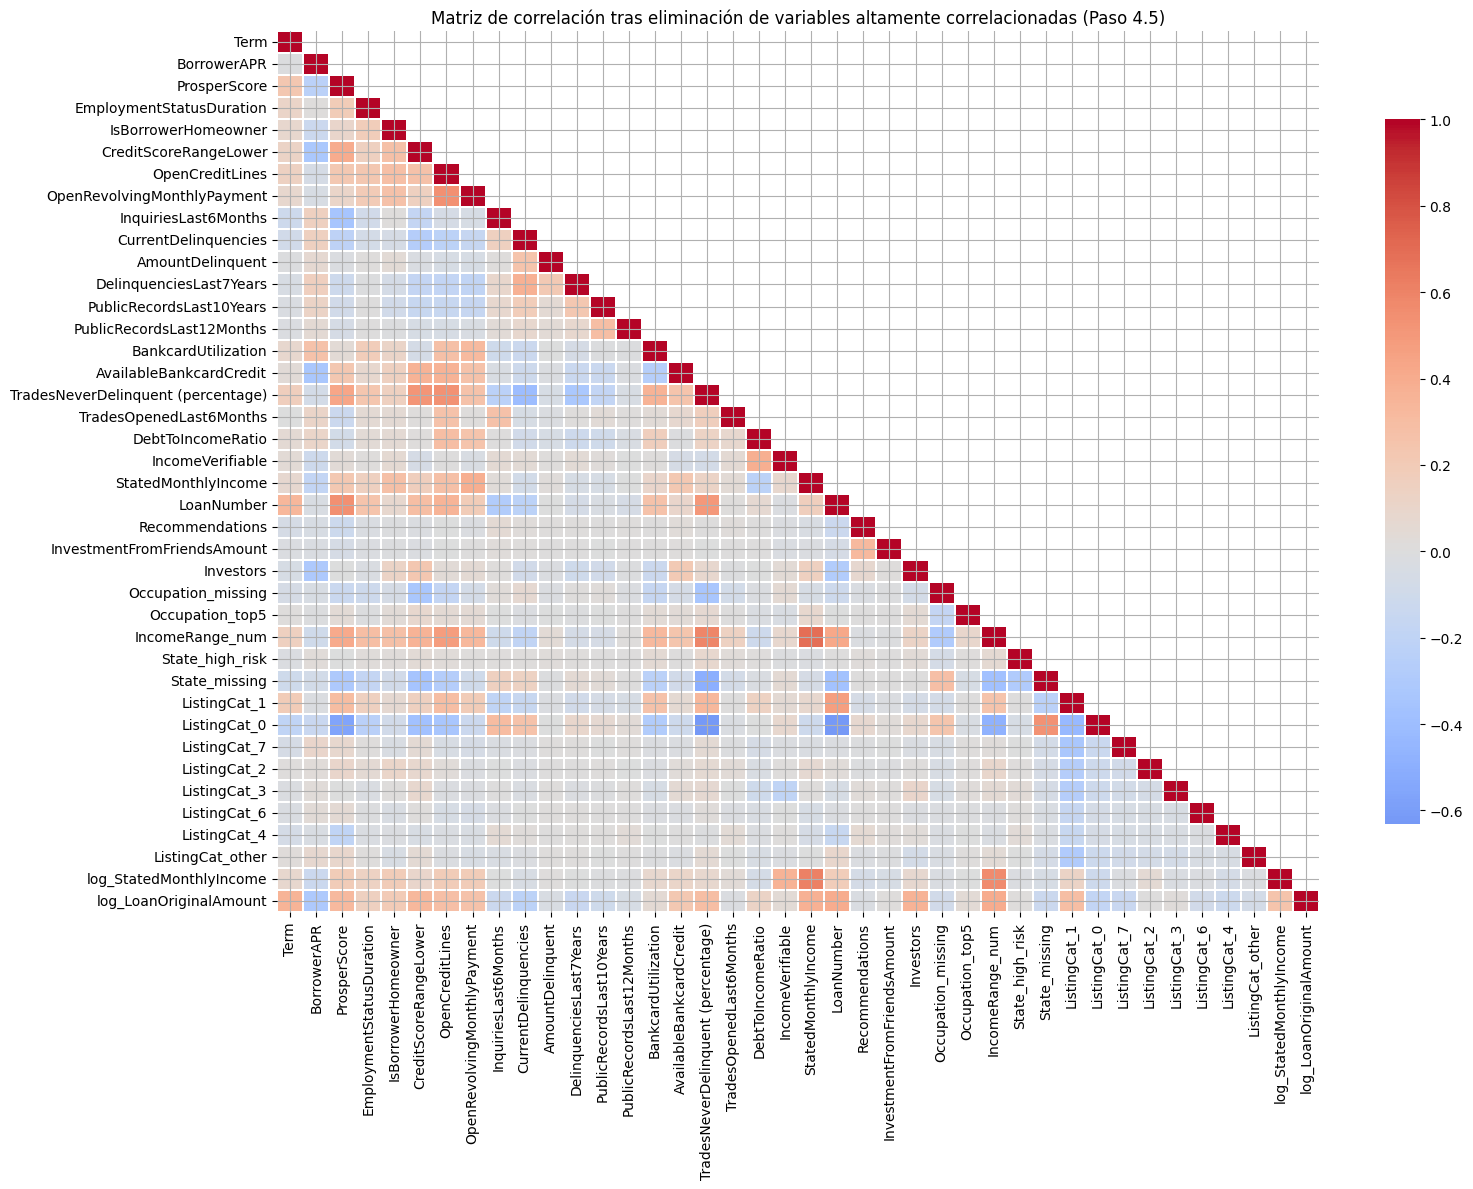

✅ No quedan pares con |r| >= 0.7 tras la eliminación.


In [29]:
# ------------------------------------------------------------
# PASO 4.6 · Recalcular y graficar matriz de correlación (post-eliminación)
# ------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas (por si hubiera dummies/object)
num_cols_post = X.select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols_post) < 2:
    print("No hay suficientes columnas numéricas para recalcular la correlación tras la eliminación.")
else:
    corr_post = X[num_cols_post].corr()

    # Heatmap (triángulo superior oculto para mejorar legibilidad)
    mask = np.triu(np.ones_like(corr_post, dtype=bool), k=1)

    plt.figure(figsize=(16, 12))
    sns.heatmap(
        corr_post,
        mask=mask,
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Matriz de correlación tras eliminación de variables altamente correlacionadas (Paso 4.5)")
    plt.tight_layout()
    plt.show()


    # (Opcional pero útil) Listado de pares que aún superan el umbral
    threshold_post = 0.7  # mantenemos el mismo umbral que en el paso 4.5
    corr_abs_post = corr_post.abs()

    pairs_post = corr_abs_post.where(mask).stack().reset_index()
    pairs_post.columns = ["var1", "var2", "corr_abs"]
    pairs_post = pairs_post[pairs_post["corr_abs"] >= threshold_post].sort_values("corr_abs", ascending=False)

    if pairs_post.empty:
        print(f"✅ No quedan pares con |r| >= {threshold_post} tras la eliminación.")
    else:
        print(f"⚠️ Aún quedan pares con |r| >= {threshold_post} tras la eliminación (revisar si quieres refinar más):")
        display(pairs_post)


Tras identificar y eliminar las variables numéricas altamente correlacionadas, se recalculó la matriz de correlaciones con el objetivo de verificar que no persistieran relaciones lineales fuertes entre las variables seleccionadas. Como se observa en la Figura X, la matriz resultante no presenta correlaciones absolutas elevadas fuera de la diagonal principal, lo que confirma que el problema de multicolinealidad ha sido mitigado. Este paso es especialmente relevante para garantizar la estabilidad e interpretabilidad de los modelos estadísticos estimados en fases posteriores del análisis.

**PASO 5: Train/Test split**

In [14]:
# PASO 5 · División en train/test estratificada

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((89998, 42), (22500, 42))

**PASO 6: GLM (Logit) con stepwise backward (p<0.005)**

In [15]:
# ============================================================
# PASO 6 · GLM LOGIT/PROBIT con STEPWISE (BACKWARD y FORWARD)
#      (95% confianza => p<0.05) usando solo TRAIN
#      Resultado: 4 modelos
#        - Logit backward / Logit forward
#        - Probit backward / Probit forward
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------------
# 6.0) Preparación de TRAIN (igual que tu pipeline)
# -------------------------------
X_train_sw = X_train.copy()
y_train_sw = y_train.copy()

# Booleanas → 0/1
bool_cols = X_train_sw.select_dtypes(include=["bool"]).columns
X_train_sw[bool_cols] = X_train_sw[bool_cols].astype(int)

# EmploymentStatus (object) → dummies (solo TRAIN)
if "EmploymentStatus" in X_train_sw.columns:
    X_train_sw = pd.get_dummies(X_train_sw, columns=["EmploymentStatus"], drop_first=True)

# Guardamos nombres de columnas (sin constante) para alinear TEST luego
feature_cols_step6 = X_train_sw.columns.tolist()

# Numérico + filtro NaN
X_train_sw = X_train_sw.apply(pd.to_numeric, errors="coerce")
y_train_sw = pd.to_numeric(y_train_sw, errors="coerce")

mask_train = y_train_sw.notna() & X_train_sw.notna().all(axis=1)
X_train_sw = X_train_sw.loc[mask_train]
y_train_sw = y_train_sw.loc[mask_train].astype(int)

# Constante
X_train_sm = sm.add_constant(X_train_sw, has_constant="add")


# -------------------------------
# 6.1) Utilidades Stepwise (Logit / Probit) con p-values
# -------------------------------
def _fit_model(model_cls, y_vec, X_df, cols, maxiter=200):
    """Ajusta Logit/Probit sobre columnas cols (incluye const). Devuelve resultado."""
    endog = y_vec.astype(float).values
    exog = X_df[cols].astype(float).values
    return model_cls(endog, exog).fit(disp=0, maxiter=maxiter)

def stepwise_backward(model_cls, X_sm, y_vec, threshold_out=0.05, maxiter=200):
    cols = list(X_sm.columns)  # incluye const

    while True:
        res = _fit_model(model_cls, y_vec, X_sm, cols, maxiter=maxiter)
        pvals = pd.Series(res.pvalues, index=cols)

        p_wo = pvals.drop("const", errors="ignore")
        worst_p = p_wo.max()
        worst_var = p_wo.idxmax()

        if worst_p > threshold_out:
            print(f"Eliminando '{worst_var}' (p = {worst_p:.4f})")
            cols.remove(worst_var)
        else:
            break

    final = _fit_model(model_cls, y_vec, X_sm, cols, maxiter=maxiter)
    return final, cols

def stepwise_forward(model_cls, X_sm, y_vec, threshold_in=0.05, maxiter=200):
    remaining = [c for c in X_sm.columns if c != "const"]
    selected = ["const"]

    while True:
        best_p = None
        best_var = None

        for var in remaining:
            trial_cols = selected + [var]
            try:
                res = _fit_model(model_cls, y_vec, X_sm, trial_cols, maxiter=maxiter)
                pval = pd.Series(res.pvalues, index=trial_cols)[var]
            except:
                continue

            if (best_p is None) or (pval < best_p):
                best_p = pval
                best_var = var

        if best_p is not None and best_p < threshold_in:
            selected.append(best_var)
            remaining.remove(best_var)
            print(f"Añadiendo '{best_var}' (p = {best_p:.4f})")
        else:
            break

    final = _fit_model(model_cls, y_vec, X_sm, selected, maxiter=maxiter)
    return final, selected


def coef_table(model_res, cols):
    return pd.DataFrame({
        "variable": cols,
        "coef": model_res.params,
        "pvalue": model_res.pvalues
    }).sort_values("pvalue")


# -------------------------------
# 6.2) LOGIT backward + forward
# -------------------------------
print("\n==============================")
print("LOGIT · STEPWISE BACKWARD")
print("==============================")
model_logit_bw, cols_logit_bw = stepwise_backward(sm.Logit, X_train_sm, y_train_sw, threshold_out=0.05, maxiter=200)
print(model_logit_bw.summary())
print("\nLOG-LIKELIHOOD (Logit backward):", float(model_logit_bw.llf))
print("AIC (Logit backward):", float(model_logit_bw.aic))
print("BIC (Logit backward):", float(model_logit_bw.bic))
display(coef_table(model_logit_bw, cols_logit_bw))


print("\n==============================")
print("LOGIT · STEPWISE FORWARD")
print("==============================")
model_logit_fw, cols_logit_fw = stepwise_forward(sm.Logit, X_train_sm, y_train_sw, threshold_in=0.05, maxiter=200)
print(model_logit_fw.summary())
print("\nLOG-LIKELIHOOD (Logit forward):", float(model_logit_fw.llf))
print("AIC (Logit forward):", float(model_logit_fw.aic))
print("BIC (Logit forward):", float(model_logit_fw.bic))
display(coef_table(model_logit_fw, cols_logit_fw))


# -------------------------------
# 6.3) PROBIT backward + forward
# -------------------------------
print("\n==============================")
print("PROBIT · STEPWISE BACKWARD")
print("==============================")
model_probit_bw, cols_probit_bw = stepwise_backward(sm.Probit, X_train_sm, y_train_sw, threshold_out=0.05, maxiter=200)
print(model_probit_bw.summary())
print("\nLOG-LIKELIHOOD (Probit backward):", float(model_probit_bw.llf))
print("AIC (Probit backward):", float(model_probit_bw.aic))
print("BIC (Probit backward):", float(model_probit_bw.bic))
display(coef_table(model_probit_bw, cols_probit_bw))


print("\n==============================")
print("PROBIT · STEPWISE FORWARD")
print("==============================")
model_probit_fw, cols_probit_fw = stepwise_forward(sm.Probit, X_train_sm, y_train_sw, threshold_in=0.05, maxiter=200)
print(model_probit_fw.summary())
print("\nLOG-LIKELIHOOD (Probit forward):", float(model_probit_fw.llf))
print("AIC (Probit forward):", float(model_probit_fw.aic))
print("BIC (Probit forward):", float(model_probit_fw.bic))
display(coef_table(model_probit_fw, cols_probit_fw))


# -------------------------------
# 6.4) Comparación variables seleccionadas (sin const)
# -------------------------------
def compare_selected(cols_bw, cols_fw, model_name="MODEL"):
    set_bw = set([c for c in cols_bw if c != "const"])
    set_fw = set([c for c in cols_fw if c != "const"])

    print(f"\nComparación variables seleccionadas ({model_name}, sin const):")
    print("Backward:", sorted(set_bw))
    print("Forward :", sorted(set_fw))
    print("¿Coinciden exactamente?", set_bw == set_fw)

    if set_bw != set_fw:
        print("\nDiferencias:")
        print("En backward y no en forward:", sorted(set_bw - set_fw))
        print("En forward y no en backward:", sorted(set_fw - set_bw))

compare_selected(cols_logit_bw, cols_logit_fw, model_name="LOGIT")
compare_selected(cols_probit_bw, cols_probit_fw, model_name="PROBIT")



LOGIT · STEPWISE BACKWARD
Eliminando 'EmploymentStatus_Self-employed' (p = 0.9926)
Eliminando 'EmploymentStatusDuration' (p = 0.6528)
Eliminando 'ListingCat_3' (p = 1.0000)
Eliminando 'ListingCat_other' (p = 0.9647)
Eliminando 'EmploymentStatus_Not employed' (p = 0.6419)
Eliminando 'TradesNeverDelinquent (percentage)' (p = 0.5560)
Eliminando 'InvestmentFromFriendsAmount' (p = 0.4242)
Eliminando 'EmploymentStatus_Retired' (p = 0.2509)
Eliminando 'ListingCat_4' (p = 0.1240)
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                89998
Model:                          Logit   Df Residuals:                    89958
Method:                           MLE   Df Model:                           39
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2861
Time:                        08:14:36   Log-Likelihood:                -27907.
converged:                       True   LL-Null:

,variable,coef,pvalue
2,BorrowerAPR,7.296719,0.000000e+00
21,LoanNumber,-0.000050,0.000000e+00
9,InquiriesLast6Months,0.076462,8.051731e-76
35,log_LoanOriginalAmount,0.364613,8.348466e-67
28,State_missing,-0.841420,1.840951e-60
10,CurrentDelinquencies,0.088520,2.750906e-57
6,CreditScoreRangeLower,-0.002418,4.354224e-57
24,Occupation_missing,-1.571670,6.140399e-51
37,EmploymentStatus_Not available,-1.166836,3.153231e-41
30,ListingCat_0,-0.492668,6.093120e-27



LOGIT · STEPWISE FORWARD
Añadiendo 'BorrowerAPR' (p = 0.0000)
Añadiendo 'ProsperScore' (p = 0.0000)
Añadiendo 'LoanNumber' (p = 0.0000)
Añadiendo 'State_missing' (p = 0.0000)
Añadiendo 'log_LoanOriginalAmount' (p = 0.0000)
Añadiendo 'InquiriesLast6Months' (p = 0.0000)
Añadiendo 'StatedMonthlyIncome' (p = 0.0000)
Añadiendo 'CurrentDelinquencies' (p = 0.0000)
Añadiendo 'TradesOpenedLast6Months' (p = 0.0000)
Añadiendo 'ListingCat_0' (p = 0.0000)
Añadiendo 'CreditScoreRangeLower' (p = 0.0000)
Añadiendo 'Term' (p = 0.0000)
Añadiendo 'EmploymentStatus_Self-employed' (p = 0.0000)
Añadiendo 'Occupation_missing' (p = 0.0000)
Añadiendo 'IsBorrowerHomeowner' (p = 0.0000)
Añadiendo 'PublicRecordsLast10Years' (p = 0.0000)
Añadiendo 'ListingCat_1' (p = 0.0000)
Añadiendo 'EmploymentStatus_Not available' (p = 0.0000)
Añadiendo 'EmploymentStatus_Full-time' (p = 0.0000)
Añadiendo 'EmploymentStatus_Part-time' (p = 0.0000)
Añadiendo 'IncomeRange_num' (p = 0.0000)
Añadiendo 'Recommendations' (p = 0.0000)


,variable,coef,pvalue
1,BorrowerAPR,7.299493,0.000000e+00
3,LoanNumber,-0.000049,0.000000e+00
6,InquiriesLast6Months,0.076457,8.396340e-76
5,log_LoanOriginalAmount,0.364756,9.779715e-67
4,State_missing,-0.841379,1.881590e-60
8,CurrentDelinquencies,0.088523,2.724288e-57
11,CreditScoreRangeLower,-0.002417,4.902557e-57
14,Occupation_missing,-1.568721,2.888856e-49
18,EmploymentStatus_Not available,-1.163897,2.545401e-39
10,ListingCat_0,-0.492274,7.951290e-27



PROBIT · STEPWISE BACKWARD
Eliminando 'EmploymentStatusDuration' (p = 0.8254)
Eliminando 'TradesNeverDelinquent (percentage)' (p = 0.7707)
Eliminando 'ListingCat_3' (p = 1.0000)
Eliminando 'ListingCat_other' (p = 0.6985)
Eliminando 'EmploymentStatus_Not employed' (p = 0.6957)
Eliminando 'EmploymentStatus_Retired' (p = 0.5861)
Eliminando 'InvestmentFromFriendsAmount' (p = 0.4082)
Eliminando 'ListingCat_4' (p = 0.3535)
Eliminando 'EmploymentStatus_Self-employed' (p = 0.2840)
Eliminando 'CurrentlyInGroup' (p = 0.1181)
                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                89998
Model:                         Probit   Df Residuals:                    89959
Method:                           MLE   Df Model:                           38
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2886
Time:                        08:21:49   Log-Likelihood:                -27810.
conv

,variable,coef,pvalue
2,BorrowerAPR,3.994948,0.000000e+00
20,LoanNumber,-0.000026,0.000000e+00
8,InquiriesLast6Months,0.046016,2.207260e-83
34,log_LoanOriginalAmount,0.208964,1.409360e-69
5,CreditScoreRangeLower,-0.001491,4.886919e-63
27,State_missing,-0.498310,2.019205e-62
9,CurrentDelinquencies,0.052602,2.073534e-62
23,Occupation_missing,-0.845973,2.172312e-44
36,EmploymentStatus_Not available,-0.627106,4.115041e-36
0,const,-1.169936,1.315653e-22



PROBIT · STEPWISE FORWARD
Añadiendo 'Term' (p = 0.0000)
Añadiendo 'BorrowerAPR' (p = 0.0000)
Añadiendo 'ProsperScore' (p = 0.0000)
Añadiendo 'LoanNumber' (p = 0.0000)
Añadiendo 'State_missing' (p = 0.0000)
Añadiendo 'InquiriesLast6Months' (p = 0.0000)
Añadiendo 'log_LoanOriginalAmount' (p = 0.0000)
Añadiendo 'StatedMonthlyIncome' (p = 0.0000)
Añadiendo 'CurrentDelinquencies' (p = 0.0000)
Añadiendo 'TradesOpenedLast6Months' (p = 0.0000)
Añadiendo 'CreditScoreRangeLower' (p = 0.0000)
Añadiendo 'ListingCat_0' (p = 0.0000)
Añadiendo 'EmploymentStatus_Self-employed' (p = 0.0000)
Añadiendo 'Occupation_missing' (p = 0.0000)
Añadiendo 'ListingCat_1' (p = 0.0000)
Añadiendo 'IsBorrowerHomeowner' (p = 0.0000)
Añadiendo 'PublicRecordsLast10Years' (p = 0.0000)
Añadiendo 'Recommendations' (p = 0.0000)
Añadiendo 'DelinquenciesLast7Years' (p = 0.0000)
Añadiendo 'EmploymentStatus_Not available' (p = 0.0000)
Añadiendo 'IncomeRange_num' (p = 0.0000)
Añadiendo 'BankcardUtilization' (p = 0.0000)
Añadiendo

,variable,coef,pvalue
2,BorrowerAPR,4.019382,0.000000e+00
4,LoanNumber,-0.000026,0.000000e+00
6,InquiriesLast6Months,0.045892,5.621628e-83
7,log_LoanOriginalAmount,0.209460,8.380556e-70
11,CreditScoreRangeLower,-0.001483,2.212097e-62
5,State_missing,-0.497681,2.970542e-62
9,CurrentDelinquencies,0.052495,3.202874e-62
14,Occupation_missing,-0.806317,2.781151e-42
20,EmploymentStatus_Not available,-0.587626,6.661731e-34
10,TradesOpenedLast6Months,0.056971,1.152646e-22



Comparación variables seleccionadas (LOGIT, sin const):
Backward: ['AmountDelinquent', 'AvailableBankcardCredit', 'BankcardUtilization', 'BorrowerAPR', 'CreditScoreRangeLower', 'CurrentDelinquencies', 'CurrentlyInGroup', 'DebtToIncomeRatio', 'DelinquenciesLast7Years', 'EmploymentStatus_Full-time', 'EmploymentStatus_Not available', 'EmploymentStatus_Other', 'EmploymentStatus_Part-time', 'IncomeRange_num', 'IncomeVerifiable', 'InquiriesLast6Months', 'Investors', 'IsBorrowerHomeowner', 'ListingCat_0', 'ListingCat_1', 'ListingCat_2', 'ListingCat_6', 'ListingCat_7', 'LoanNumber', 'Occupation_missing', 'Occupation_top5', 'OpenCreditLines', 'OpenRevolvingMonthlyPayment', 'ProsperScore', 'PublicRecordsLast10Years', 'PublicRecordsLast12Months', 'Recommendations', 'State_high_risk', 'State_missing', 'StatedMonthlyIncome', 'Term', 'TradesOpenedLast6Months', 'log_LoanOriginalAmount', 'log_StatedMonthlyIncome']
Forward : ['AmountDelinquent', 'AvailableBankcardCredit', 'BankcardUtilization', 'Borro

**PASO 7: MÉTRICAS Y CURVAS DEL GLM STEPWISE**

REPORTE COMPLETO (TRAIN y TEST) · LOGIT/PROBIT · Forward/Backward


,Modelo,Split,N_vars(sin_const),Accuracy,Precision,Recall,F1,ROC_AUC,LogLik,AIC,BIC
0,LOGIT_Backward,TRAIN,39,0.861452,0.631832,0.279297,0.387363,0.858211,-27907.443713,55894.887426,56271.189135
1,LOGIT_Backward,TEST,39,0.863200,0.650233,0.276566,0.388072,0.859085,-27907.443713,55894.887426,56271.189135
2,LOGIT_Forward,TRAIN,40,0.861452,0.631832,0.279297,0.387363,0.858215,-27907.431125,55896.862250,56282.571502
3,LOGIT_Forward,TEST,40,0.863289,0.650699,0.277132,0.388712,0.859088,-27907.431125,55896.862250,56282.571502
4,PROBIT_Backward,TRAIN,38,0.861652,0.640908,0.267961,0.377917,0.858433,-27810.023915,55698.047830,56064.941997
5,PROBIT_Backward,TEST,38,0.863467,0.661029,0.265798,0.379143,0.859413,-27810.023915,55698.047830,56064.941997
6,PROBIT_Forward,TRAIN,38,0.861686,0.640805,0.268599,0.378532,0.858456,-27811.203058,55700.406116,56067.300282
7,PROBIT_Forward,TEST,38,0.863200,0.659364,0.264381,0.377427,0.859386,-27811.203058,55700.406116,56067.300282


|    | Modelo          | Split   |   N_vars(sin_const) |   Accuracy |   Precision |   Recall |       F1 |   ROC_AUC |   LogLik |     AIC |     BIC |
|---:|:----------------|:--------|--------------------:|-----------:|------------:|---------:|---------:|----------:|---------:|--------:|--------:|
|  0 | LOGIT_Backward  | TRAIN   |                  39 |   0.861452 |    0.631832 | 0.279297 | 0.387363 |  0.858211 | -27907.4 | 55894.9 | 56271.2 |
|  1 | LOGIT_Backward  | TEST    |                  39 |   0.8632   |    0.650233 | 0.276566 | 0.388072 |  0.859085 | -27907.4 | 55894.9 | 56271.2 |
|  2 | LOGIT_Forward   | TRAIN   |                  40 |   0.861452 |    0.631832 | 0.279297 | 0.387363 |  0.858215 | -27907.4 | 55896.9 | 56282.6 |
|  3 | LOGIT_Forward   | TEST    |                  40 |   0.863289 |    0.650699 | 0.277132 | 0.388712 |  0.859088 | -27907.4 | 55896.9 | 56282.6 |
|  4 | PROBIT_Backward | TRAIN   |                  38 |   0.861652 |    0.640908 | 0.267961 | 0.377917 | 

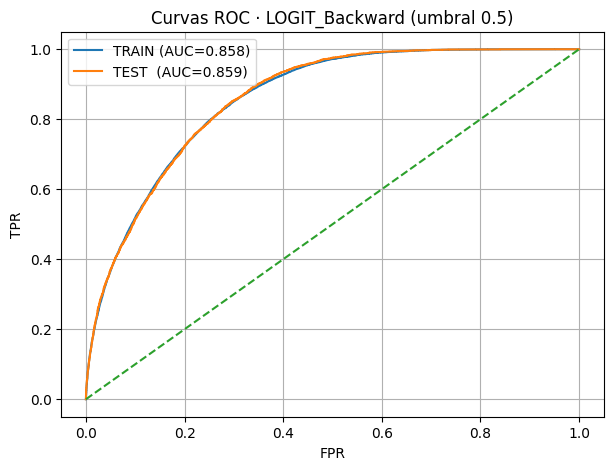

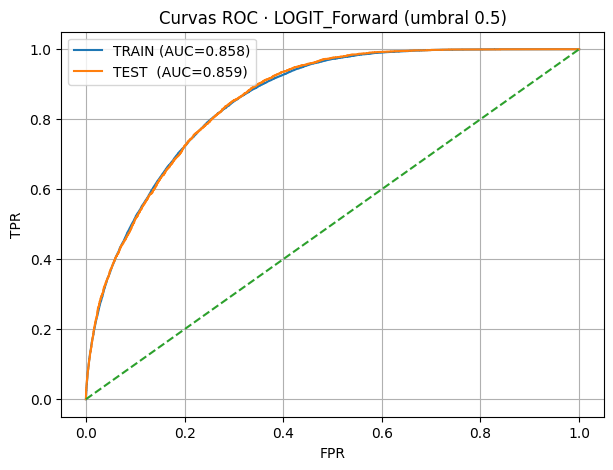

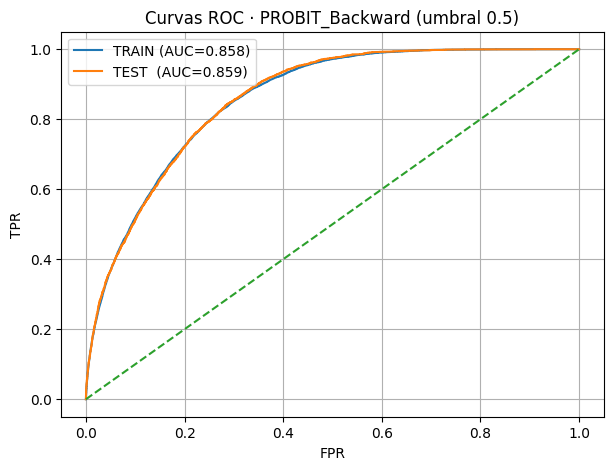

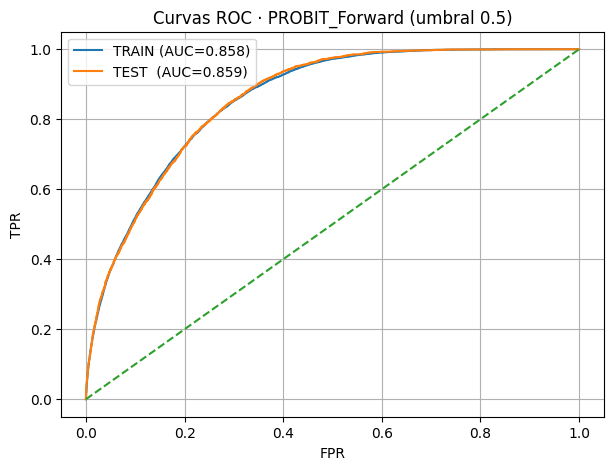

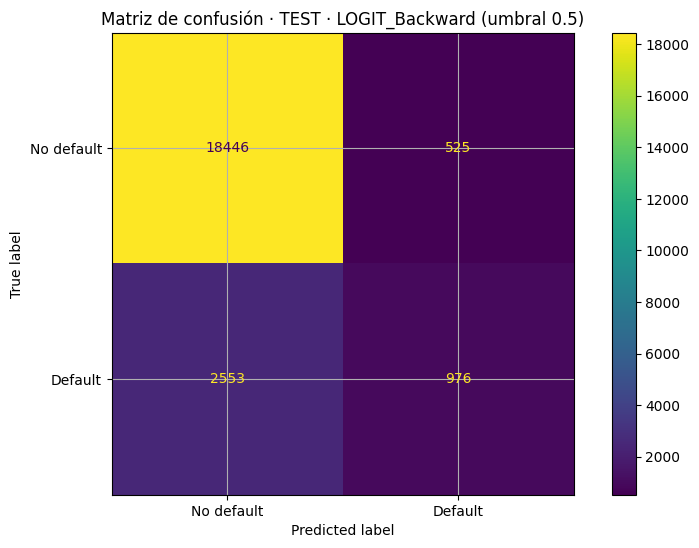

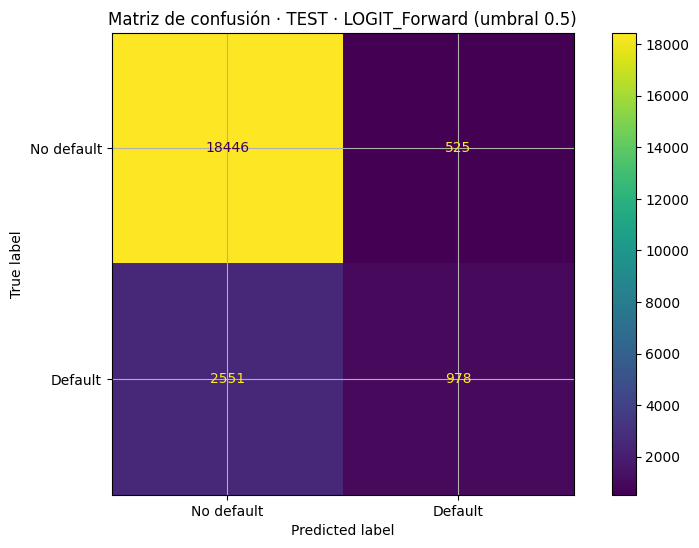

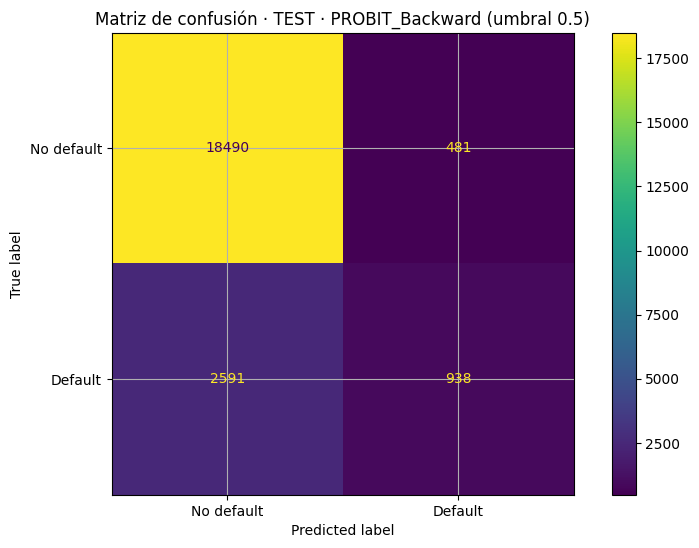

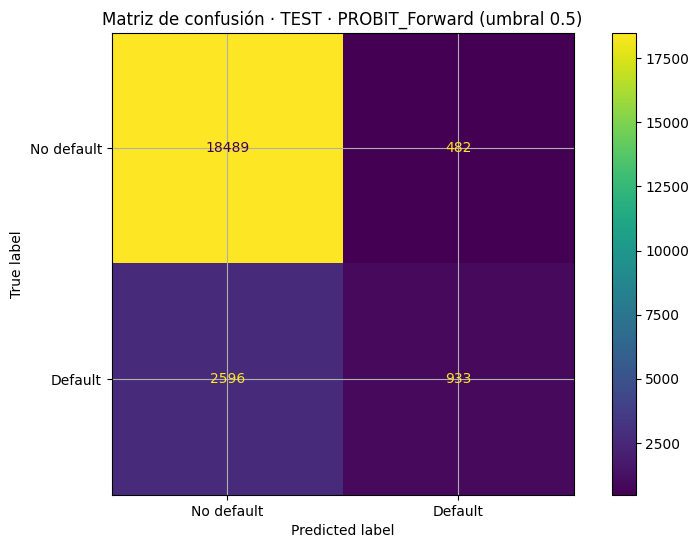

In [16]:
# ============================================================
# PASO 7 · Reporte final (TRAIN y TEST) para 4 modelos:
#   - LOGIT Backward, LOGIT Forward, PROBIT Backward, PROBIT Forward
# Incluye: Accuracy, Precision, Recall, F1, ROC_AUC + Log-Likelihood + AIC + BIC
# + Curvas ROC + Matriz de confusión (TEST)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# =========================
# 0) Comprobaciones mínimas
# =========================
required = [
    "X_train", "X_test", "y_train", "y_test",
    "feature_cols_step6",
    "X_train_sm", "y_train_sw",
    "model_logit_bw", "cols_logit_bw",
    "model_logit_fw", "cols_logit_fw",
    "model_probit_bw", "cols_probit_bw",
    "model_probit_fw", "cols_probit_fw"
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables para PASO 7: {missing}. Ejecuta el PASO 6 completo.")


# ==========================================================
# 1) Preparación TEST (mismo pipeline de TRAIN del PASO 6)
# ==========================================================
def prepare_like_train_step6(X_raw, y_raw, feature_cols_step6):
    Xp = X_raw.copy()
    yp = y_raw.copy()

    # bool -> int
    bool_cols = Xp.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        Xp[bool_cols] = Xp[bool_cols].astype(int)

    # EmploymentStatus dummies
    if "EmploymentStatus" in Xp.columns:
        Xp = pd.get_dummies(Xp, columns=["EmploymentStatus"], drop_first=True)

    # Alinear columnas EXACTAS de TRAIN (sin constante)
    for col in feature_cols_step6:
        if col not in Xp.columns:
            Xp[col] = 0

    # Eliminar columnas extra y reordenar
    Xp = Xp[feature_cols_step6]

    # numérico
    Xp = Xp.apply(pd.to_numeric, errors="coerce")
    yp = pd.to_numeric(yp, errors="coerce")

    # drop NaN
    mask = yp.notna() & Xp.notna().all(axis=1)
    Xp = Xp.loc[mask]
    yp = yp.loc[mask].astype(int)

    # constante
    Xp_sm = sm.add_constant(Xp, has_constant="add").astype(float)
    return Xp_sm, yp

X_test_sm, y_test_sw = prepare_like_train_step6(X_test, y_test, feature_cols_step6)


# ==========================================================
# 2) Funciones de métricas y predicción para statsmodels
# ==========================================================
def get_pred_proba(model, X_sm, cols):
    # model entrenado con arrays -> predecimos con .values
    return model.predict(X_sm[cols].astype(float).values)

def binarize(p, thr=0.5):
    return (p >= thr).astype(int)

def metrics_block(y_true, y_pred, y_proba):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_true, y_proba)
    }

def add_fit_stats(model):
    return {
        "LogLik": float(model.llf),
        "AIC": float(model.aic),
        "BIC": float(model.bic)
    }


# ==========================================================
# 3) Evaluación (TRAIN y TEST) para cada modelo
# ==========================================================
results = []

MODELS = [
    ("LOGIT_Backward",  model_logit_bw,   cols_logit_bw),
    ("LOGIT_Forward",   model_logit_fw,   cols_logit_fw),
    ("PROBIT_Backward", model_probit_bw,  cols_probit_bw),
    ("PROBIT_Forward",  model_probit_fw,  cols_probit_fw),
]

for name, mdl, cols in MODELS:
    # TRAIN
    p_tr = get_pred_proba(mdl, X_train_sm, cols)
    yhat_tr = binarize(p_tr, 0.5)
    m_tr = metrics_block(y_train_sw, yhat_tr, p_tr)

    # TEST
    p_te = get_pred_proba(mdl, X_test_sm, cols)
    yhat_te = binarize(p_te, 0.5)
    m_te = metrics_block(y_test_sw, yhat_te, p_te)

    # stats de ajuste (fit en TRAIN)
    fit_stats = add_fit_stats(mdl)

    results.append({
        "Modelo": name,
        "Split": "TRAIN",
        **m_tr,
        **fit_stats,
        "N_vars(sin_const)": len([c for c in cols if c != "const"])
    })
    results.append({
        "Modelo": name,
        "Split": "TEST",
        **m_te,
        **fit_stats,  # se repite porque proviene del fit (TRAIN)
        "N_vars(sin_const)": len([c for c in cols if c != "const"])
    })

df_report = pd.DataFrame(results)

order_cols = ["Modelo","Split","N_vars(sin_const)","Accuracy","Precision","Recall","F1","ROC_AUC","LogLik","AIC","BIC"]
df_report = df_report[order_cols]

print("REPORTE COMPLETO (TRAIN y TEST) · LOGIT/PROBIT · Forward/Backward")
display(df_report)

print(df_report.to_markdown())

latex_table = df_report.to_latex(
    index=False,
    caption="Resultados comparativos de los modelos",
    label="tab:modelos",
    float_format="%.4f",
    bold_rows=False,
    escape=False
)
print(latex_table)

# ==========================================================
# 4) Curvas ROC (TRAIN y TEST) para los 4 modelos
# ==========================================================
def plot_roc_for_model(name, mdl, cols):
    p_tr = get_pred_proba(mdl, X_train_sm, cols)
    p_te = get_pred_proba(mdl, X_test_sm, cols)

    fpr_tr, tpr_tr, _ = roc_curve(y_train_sw, p_tr)
    fpr_te, tpr_te, _ = roc_curve(y_test_sw, p_te)

    auc_tr = roc_auc_score(y_train_sw, p_tr)
    auc_te = roc_auc_score(y_test_sw, p_te)

    plt.figure(figsize=(7,5))
    plt.plot(fpr_tr, tpr_tr, label=f"TRAIN (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"TEST  (AUC={auc_te:.3f})")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"Curvas ROC · {name} (umbral 0.5)")
    plt.legend()
    plt.show()

for name, mdl, cols in MODELS:
    plot_roc_for_model(name, mdl, cols)


# ==========================================================
# 5) Matrices de confusión (TEST) para los 4 modelos
# ==========================================================
def plot_cm_test(name, mdl, cols):
    p_te = get_pred_proba(mdl, X_test_sm, cols)
    yhat_te = binarize(p_te, 0.5)
    cm = confusion_matrix(y_test_sw, yhat_te)
    ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d")
    plt.title(f"Matriz de confusión · TEST · {name} (umbral 0.5)")
    plt.show()

for name, mdl, cols in MODELS:
    plot_cm_test(name, mdl, cols)


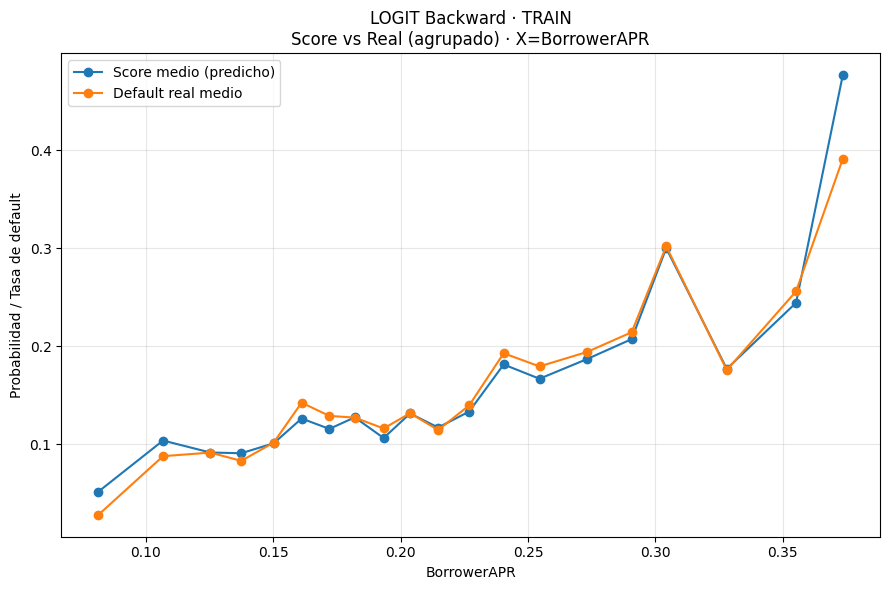

,x_mean,p_mean,y_mean,n
0,0.081443,0.051701,0.028058,4562
1,0.106777,0.103751,0.087798,4442
2,0.125303,0.091536,0.091453,4516
3,0.137457,0.090780,0.083036,4480
4,0.150186,0.100925,0.101639,4821
5,0.161147,0.126179,0.142385,4235
6,0.172051,0.115609,0.128856,4571
7,0.181999,0.127408,0.127147,4483
8,0.193341,0.106297,0.116041,4395
9,0.203700,0.131325,0.131614,4498


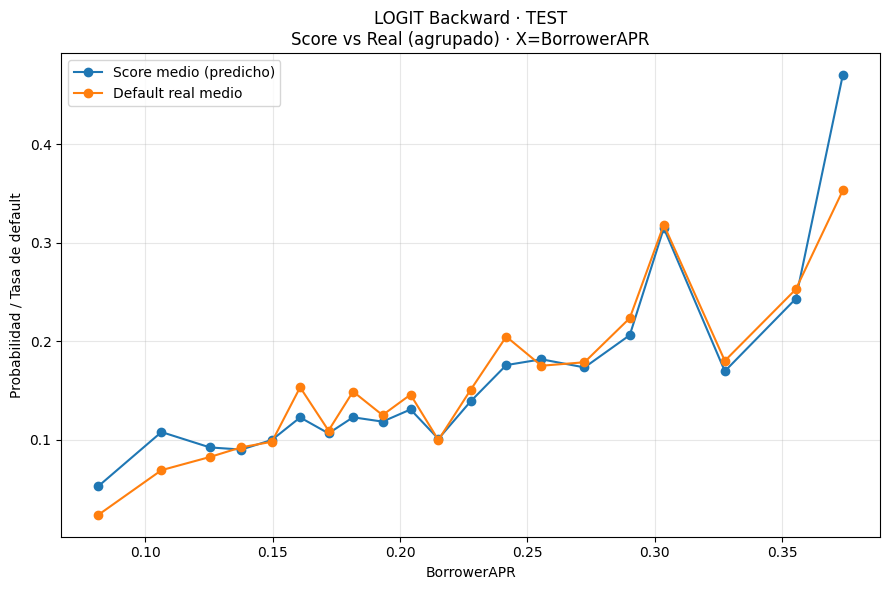

,x_mean,p_mean,y_mean,n
0,0.081716,0.052858,0.023768,1136
1,0.106415,0.107703,0.068996,1116
2,0.125440,0.092072,0.082384,1141
3,0.137746,0.089926,0.092199,1128
4,0.149751,0.099705,0.097826,1104
5,0.160816,0.122506,0.153097,1130
6,0.171956,0.106351,0.109155,1136
7,0.181567,0.122671,0.148804,1129
8,0.193145,0.118263,0.124887,1105
9,0.204139,0.130607,0.145648,1126


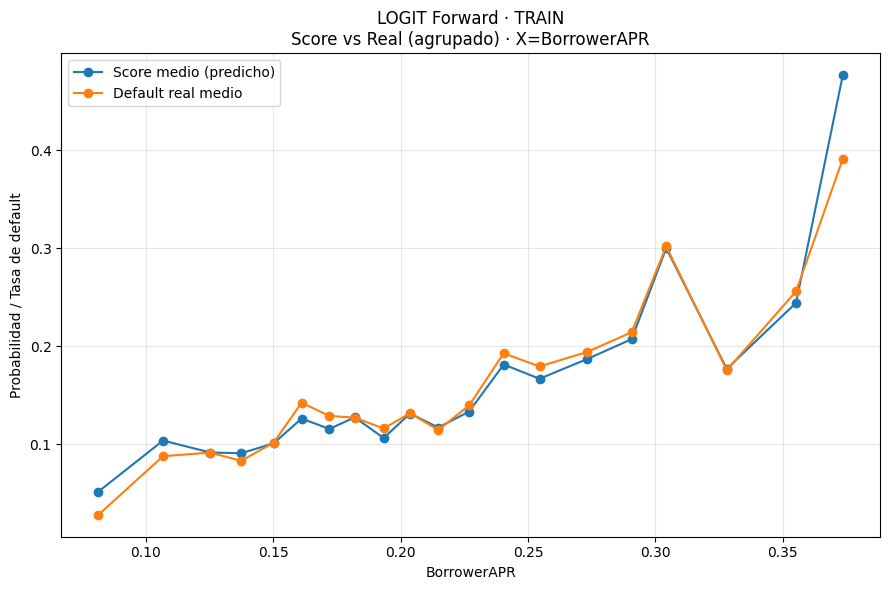

,x_mean,p_mean,y_mean,n
0,0.081443,0.051692,0.028058,4562
1,0.106777,0.103745,0.087798,4442
2,0.125303,0.091538,0.091453,4516
3,0.137457,0.090780,0.083036,4480
4,0.150186,0.100930,0.101639,4821
5,0.161147,0.126176,0.142385,4235
6,0.172051,0.115607,0.128856,4571
7,0.181999,0.127410,0.127147,4483
8,0.193341,0.106302,0.116041,4395
9,0.203700,0.131318,0.131614,4498


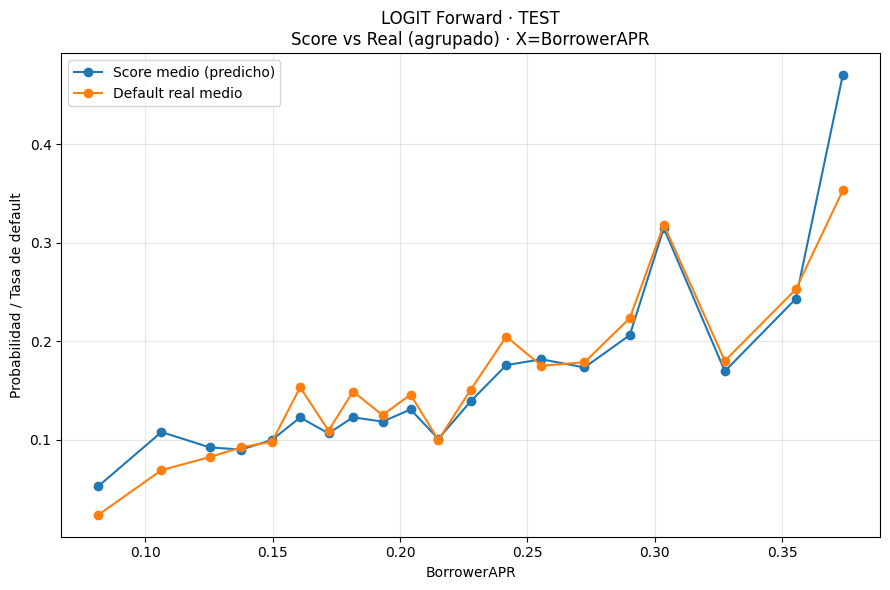

,x_mean,p_mean,y_mean,n
0,0.081716,0.052850,0.023768,1136
1,0.106415,0.107701,0.068996,1116
2,0.125440,0.092067,0.082384,1141
3,0.137746,0.089925,0.092199,1128
4,0.149751,0.099715,0.097826,1104
5,0.160816,0.122506,0.153097,1130
6,0.171956,0.106369,0.109155,1136
7,0.181567,0.122675,0.148804,1129
8,0.193145,0.118273,0.124887,1105
9,0.204139,0.130604,0.145648,1126


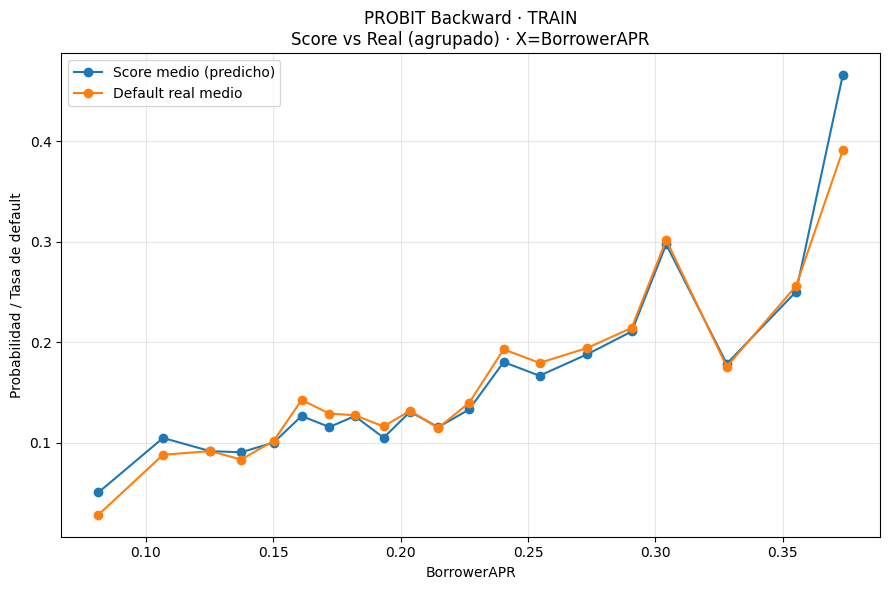

,x_mean,p_mean,y_mean,n
0,0.081443,0.050312,0.028058,4562
1,0.106777,0.104535,0.087798,4442
2,0.125303,0.091409,0.091453,4516
3,0.137457,0.090276,0.083036,4480
4,0.150186,0.099953,0.101639,4821
5,0.161147,0.126385,0.142385,4235
6,0.172051,0.115424,0.128856,4571
7,0.181999,0.126274,0.127147,4483
8,0.193341,0.104811,0.116041,4395
9,0.203700,0.130630,0.131614,4498


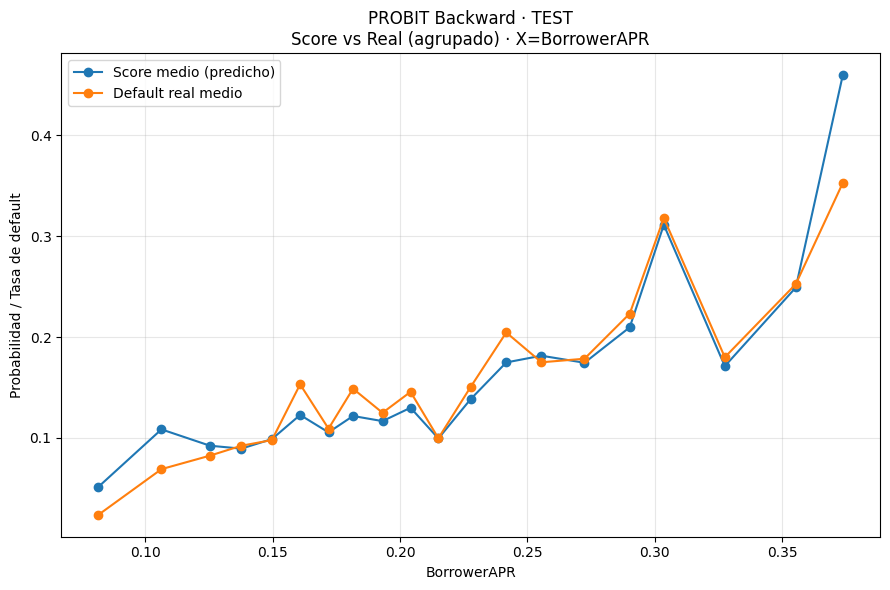

,x_mean,p_mean,y_mean,n
0,0.081716,0.051510,0.023768,1136
1,0.106415,0.108436,0.068996,1116
2,0.125440,0.092241,0.082384,1141
3,0.137746,0.089332,0.092199,1128
4,0.149751,0.098791,0.097826,1104
5,0.160816,0.122751,0.153097,1130
6,0.171956,0.105482,0.109155,1136
7,0.181567,0.121709,0.148804,1129
8,0.193145,0.116626,0.124887,1105
9,0.204139,0.129879,0.145648,1126


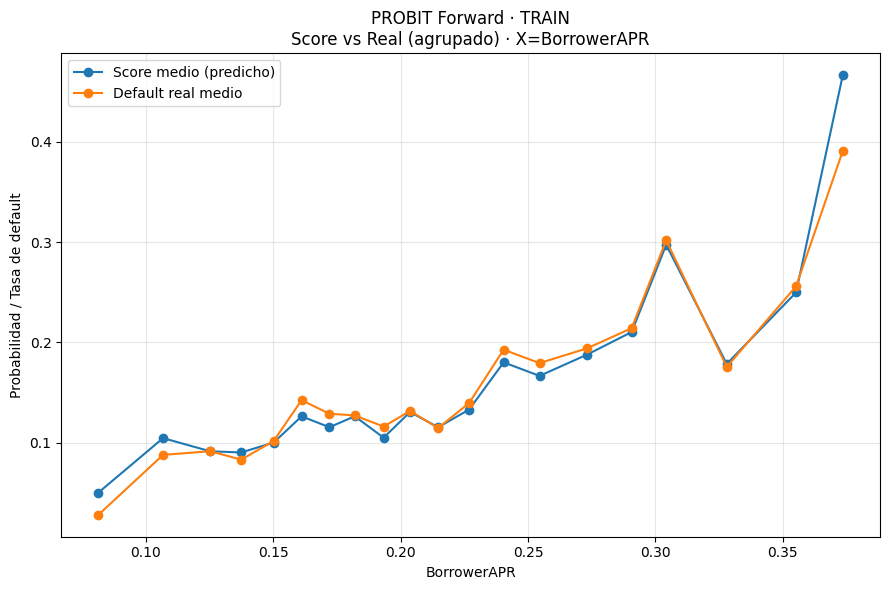

,x_mean,p_mean,y_mean,n
0,0.081443,0.050227,0.028058,4562
1,0.106777,0.104503,0.087798,4442
2,0.125303,0.091339,0.091453,4516
3,0.137457,0.090212,0.083036,4480
4,0.150186,0.100075,0.101639,4821
5,0.161147,0.126251,0.142385,4235
6,0.172051,0.115384,0.128856,4571
7,0.181999,0.126298,0.127147,4483
8,0.193341,0.104933,0.116041,4395
9,0.203700,0.130565,0.131614,4498


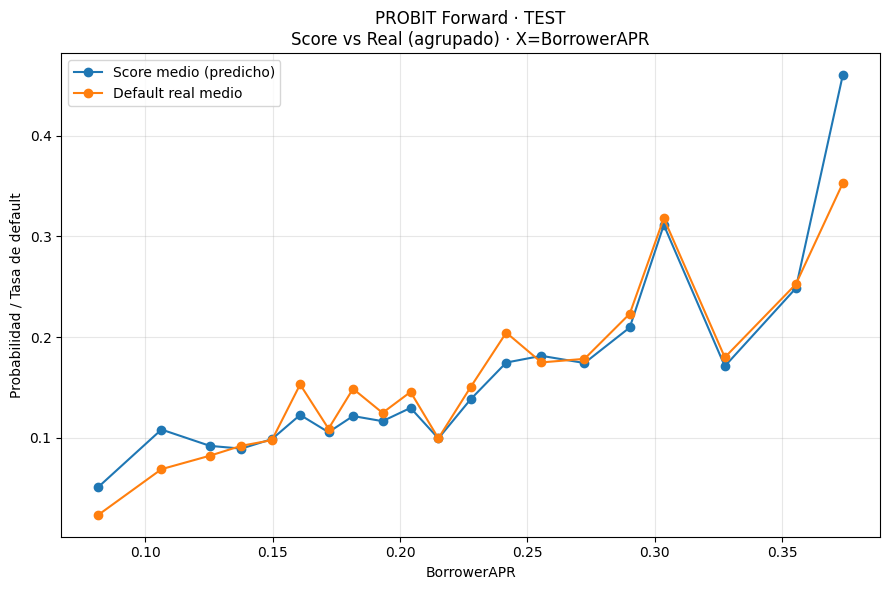

,x_mean,p_mean,y_mean,n
0,0.081716,0.051454,0.023768,1136
1,0.106415,0.108345,0.068996,1116
2,0.125440,0.092130,0.082384,1141
3,0.137746,0.089401,0.092199,1128
4,0.149751,0.098830,0.097826,1104
5,0.160816,0.122857,0.153097,1130
6,0.171956,0.105692,0.109155,1136
7,0.181567,0.121736,0.148804,1129
8,0.193145,0.116645,0.124887,1105
9,0.204139,0.129824,0.145648,1126


In [17]:
# ============================================================
# PASO 7 · Gráficos bidimensionales (score vs variable)
#        + comparación con valor real (default rate)
#        (4 modelos · TRAIN y TEST · agrupado para no solapar)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------------
# 7.0) Preparar TEST alineado exactamente como TRAIN (step6)
# ------------------------------------------------------------
X_test_sw = X_test.copy()

# booleanas → 0/1 (por si existieran)
bool_cols_test = X_test_sw.select_dtypes(include=["bool"]).columns
X_test_sw[bool_cols_test] = X_test_sw[bool_cols_test].astype(int)

# dummies EmploymentStatus igual que TRAIN
if "EmploymentStatus" in X_test_sw.columns:
    X_test_sw = pd.get_dummies(X_test_sw, columns=["EmploymentStatus"], drop_first=True)

# Alinear columnas a las de TRAIN (feature_cols_step6)
# Si faltan columnas en TEST, las creamos a 0 (p.ej. alguna dummy no aparece en TEST)
for c in feature_cols_step6:
    if c not in X_test_sw.columns:
        X_test_sw[c] = 0

# Si sobran columnas, las quitamos
X_test_sw = X_test_sw[feature_cols_step6]

# numérico + filtro NaN (como TRAIN)
X_test_sw = X_test_sw.apply(pd.to_numeric, errors="coerce")
y_test_sw = pd.to_numeric(y_test, errors="coerce")

mask_test = y_test_sw.notna() & X_test_sw.notna().all(axis=1)
X_test_sw = X_test_sw.loc[mask_test]
y_test_sw = y_test_sw.loc[mask_test].astype(int)

# const
X_test_sm = sm.add_constant(X_test_sw, has_constant="add")


# ------------------------------------------------------------
# 7.1) Calcular scores (probabilidades) para los 4 modelos
# ------------------------------------------------------------
def predict_proba(model_res, X_sm, cols):
    return model_res.predict(X_sm[cols].astype(float).values)

# TRAIN df base
df_train_scores = X_train_sm.copy()
df_train_scores["y_real"] = y_train_sw.values

df_train_scores["p_logit_bw"]   = predict_proba(model_logit_bw,   X_train_sm, cols_logit_bw)
df_train_scores["p_logit_fw"]   = predict_proba(model_logit_fw,   X_train_sm, cols_logit_fw)
df_train_scores["p_probit_bw"]  = predict_proba(model_probit_bw,  X_train_sm, cols_probit_bw)
df_train_scores["p_probit_fw"]  = predict_proba(model_probit_fw,  X_train_sm, cols_probit_fw)

# TEST df base
df_test_scores = X_test_sm.copy()
df_test_scores["y_real"] = y_test_sw.values

df_test_scores["p_logit_bw"]   = predict_proba(model_logit_bw,   X_test_sm, cols_logit_bw)
df_test_scores["p_logit_fw"]   = predict_proba(model_logit_fw,   X_test_sm, cols_logit_fw)
df_test_scores["p_probit_bw"]  = predict_proba(model_probit_bw,  X_test_sm, cols_probit_bw)
df_test_scores["p_probit_fw"]  = predict_proba(model_probit_fw,  X_test_sm, cols_probit_fw)


# ------------------------------------------------------------
# 7.2) Función: agrupar (bins) y sacar medias (evita solapamiento)
#      - X: variable (binning por cuantiles)
#      - Y: score medio y default real medio
# ------------------------------------------------------------
def grouped_curve_table(df, x_col, p_col, y_col="y_real", n_bins=20):
    work = df[[x_col, p_col, y_col]].copy()
    work = work.replace([np.inf, -np.inf], np.nan).dropna()

    # Si la variable tiene pocos valores únicos, reducimos bins
    uniq = work[x_col].nunique()
    bins = int(min(n_bins, max(3, uniq)))  # mínimo 3 bins

    # Binning por cuantiles (mejor para distribución sesgada)
    # duplicates="drop" evita error si hay muchos valores repetidos
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")

    agg = (
        work.groupby("bin", observed=True)
            .agg(
                x_mean=(x_col, "mean"),
                p_mean=(p_col, "mean"),
                y_mean=(y_col, "mean"),
                n=(y_col, "size")
            )
            .reset_index(drop=True)
            .sort_values("x_mean")
    )
    return agg


# ------------------------------------------------------------
# 7.3) Función: plot (línea score medio vs default real medio)
# ------------------------------------------------------------
def plot_score_vs_real(df, x_col, p_col, sample_name, model_name, n_bins=20):
    agg = grouped_curve_table(df, x_col, p_col, y_col="y_real", n_bins=n_bins)

    plt.figure(figsize=(9, 6))
    plt.plot(agg["x_mean"], agg["p_mean"], marker="o", label="Score medio (predicho)")
    plt.plot(agg["x_mean"], agg["y_mean"], marker="o", label="Default real medio")

    plt.title(f"{model_name} · {sample_name}\nScore vs Real (agrupado) · X={x_col}")
    plt.xlabel(x_col)
    plt.ylabel("Probabilidad / Tasa de default")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Mostrar tabla (para TFG va muy bien)
    display(agg)


# ------------------------------------------------------------
# 7.4) EJECUCIÓN: variables a probar (las que has pedido)
#     Nota: usa nombres EXACTOS como estén en X_train_sm (sin dummies)
# ------------------------------------------------------------
features_to_try = [
    "BorrowerAPR",
    "CreditScoreRangeLower",
    "CreditScoreRangeUpper",
    "log_LoanOriginalAmount",
    "BankcardUtilization",
    "AvailableBankcardCredit",
    "AmountDelinquent"
]

models_map = {
    "LOGIT Backward":  "p_logit_bw",
    "LOGIT Forward":   "p_logit_fw",
    "PROBIT Backward": "p_probit_bw",
    "PROBIT Forward":  "p_probit_fw"
}

# Cambia aquí la variable que quieras probar (una por una)
feature = "BorrowerAPR"   # <-- CAMBIA A features to try, etc.

# Ejecutar TRAIN y TEST para los 4 modelos con esa variable
for model_name, pcol in models_map.items():
    if feature in df_train_scores.columns and feature in df_test_scores.columns:
        plot_score_vs_real(df_train_scores, feature, pcol, sample_name="TRAIN", model_name=model_name, n_bins=20)
        plot_score_vs_real(df_test_scores,  feature, pcol, sample_name="TEST",  model_name=model_name, n_bins=20)
    else:
        print(f"⚠️ La variable '{feature}' no está en el dataframe (quizá fue eliminada o se transformó).")


Cambiar feature = "BorrowerAPR" por borrowerRate, loanOriginalAmount o CreditScoreRangeLower, etc etc y asi nos genera los graficos y las tablas correspondientes

In [18]:
'X' in globals()


True

In [19]:
# COMPROBACIÓN Y RECONSTRUCCIÓN DE X Y y (si es necesario)

if "X" not in globals() or "y" not in globals():
    print("⚠️ X o y no estaban definidos. Reconstruyendo desde df_model...")

    cols_excluir_modelo = ["LoanStatus", "default"]
    feature_cols = [c for c in df_model.columns if c not in cols_excluir_modelo]

    X = df_model[feature_cols].copy()
    y = df_model["default"].copy()

    print("Reconstruido X con", X.shape[1], "variables.")

# Confirmación
print(f"OK ✔️  X y y listos. X: {X.shape}, y: {y.shape}")


OK ✔️  X y y listos. X: (112498, 42), y: (112498,)


**PASO 8: MODELOS ML: SMOTE + LOGIT, RF, RF + SMOTE**

=== SMOTE + Logit ===


,Accuracy,Precision,Recall,F1,ROC_AUC
SMOTE+Logit,0.7425,0.3593,0.8189,0.4994,0.8576


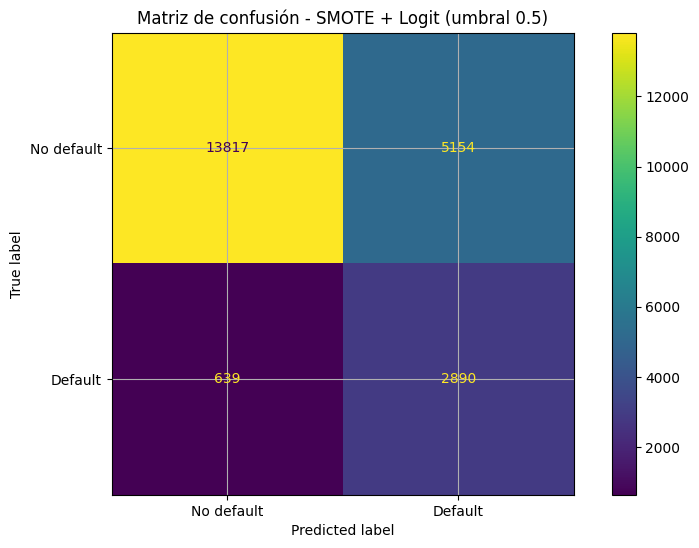

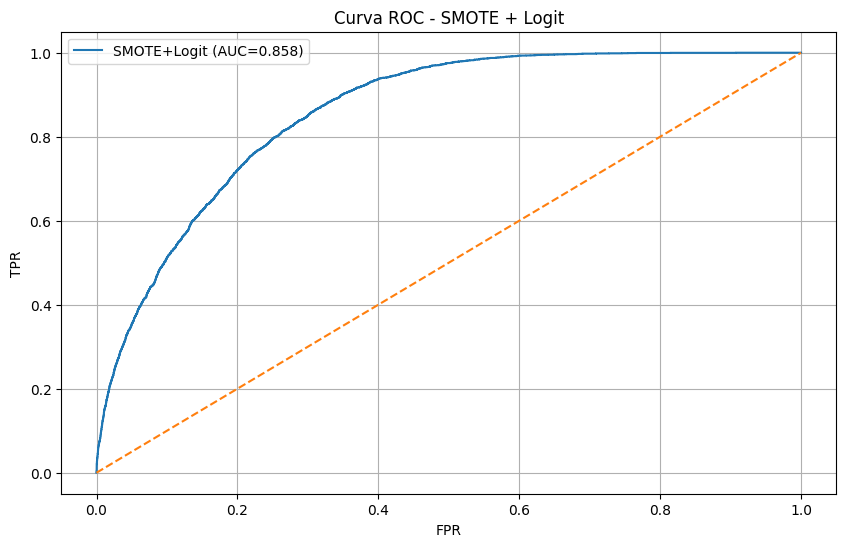

=== Random Forest ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.8605,0.6653,0.223,0.334,0.8643


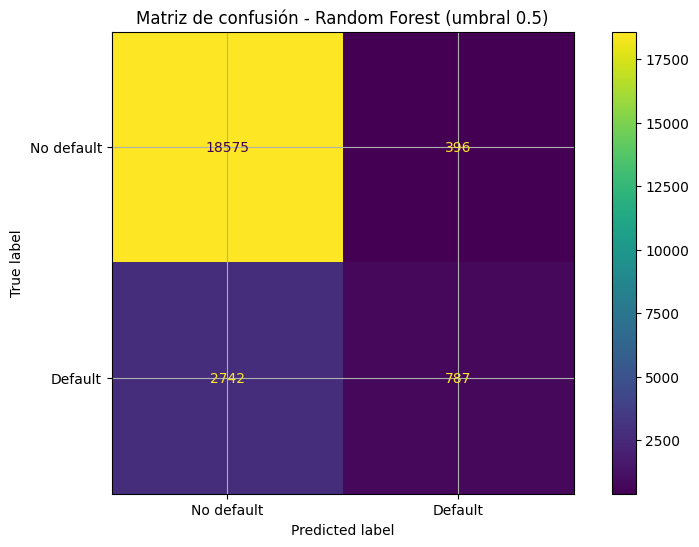

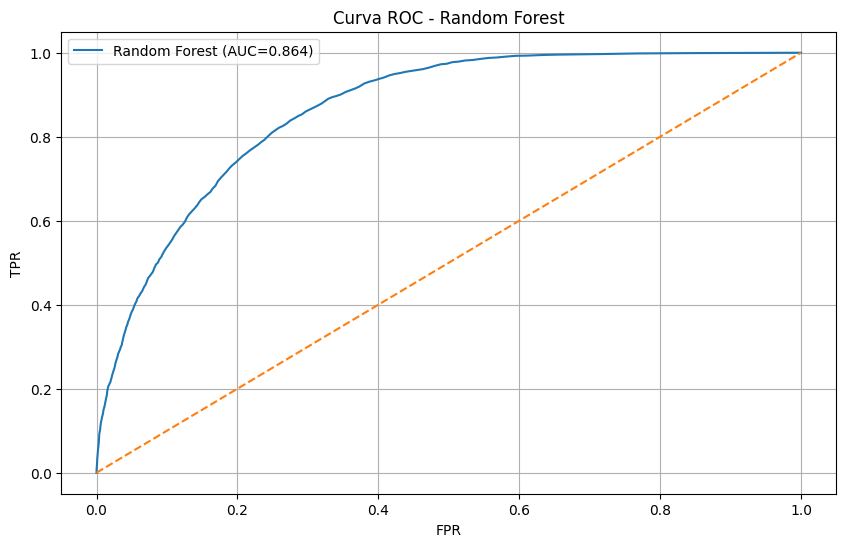

Top 20 variables más importantes (RF):


,feature_importance
LoanNumber,0.1615
BorrowerAPR,0.0774
Investors,0.0716
ProsperScore,0.0668
CreditScoreRangeLower,0.0504
AvailableBankcardCredit,0.0434
OpenRevolvingMonthlyPayment,0.0414
log_StatedMonthlyIncome,0.0382
StatedMonthlyIncome,0.0381
log_LoanOriginalAmount,0.0374


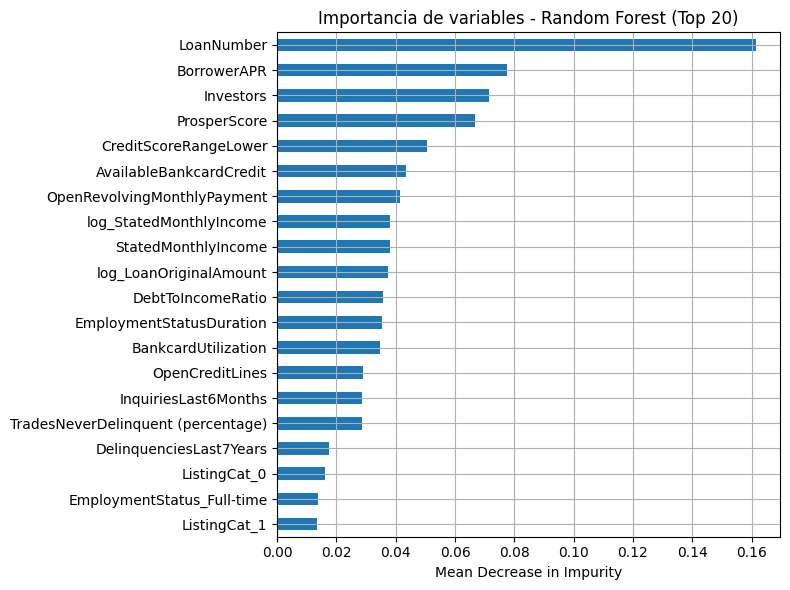

=== RF + SMOTE ===


,Accuracy,Precision,Recall,F1,ROC_AUC
RF + SMOTE,0.8604,0.5929,0.3508,0.4408,0.859


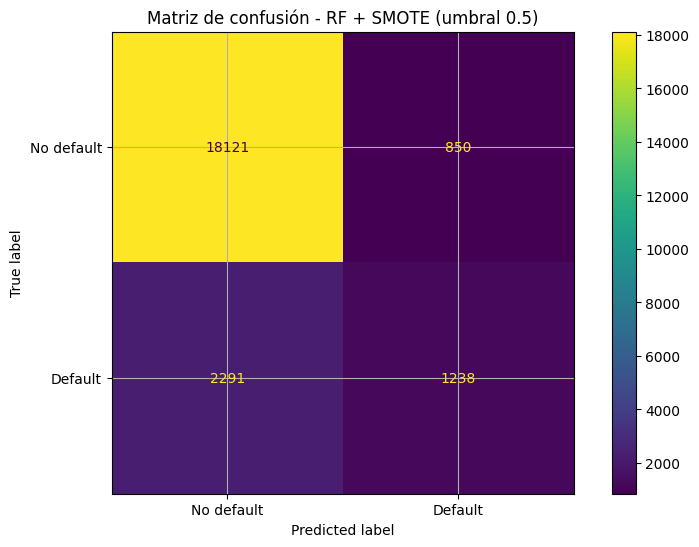

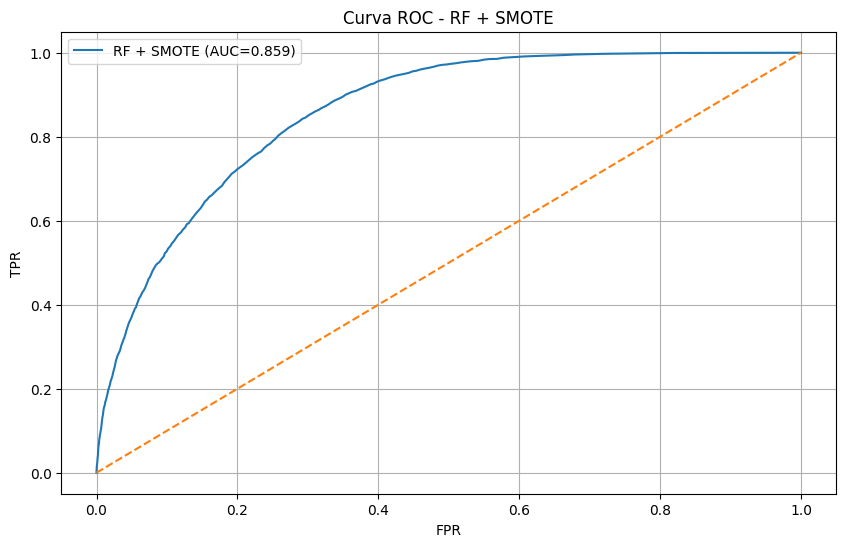

In [20]:
# PASO 8 · Modelos ML (SMOTE + Logit, Random Forest, RF + SMOTE)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMBLEARN_OK = True
except Exception:
    IMBLEARN_OK = False
    print("⚠️ imbalanced-learn no disponible. SMOTE se omitirá.")
    IMBLEARN_OK = False

# Variables numéricas / categóricas basadas en X_train (más robusto)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

def resumen_metricas(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

# 8.1 SMOTE + Logit
if IMBLEARN_OK:
    numeric_transformer_sm = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer_sm = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder(drop="first"))
    ])

    preprocess_sm = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_sm, num_features),
            ("cat", categorical_transformer_sm, cat_features)
        ],
        remainder="drop", verbose_feature_names_out=False
    )

    smote_logit_clf = ImbPipeline(steps=[
        ("preprocess", preprocess_sm),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ])

    smote_logit_clf.fit(X_train, y_train)
    y_proba_sm = smote_logit_clf.predict_proba(X_test)[:, 1]
    y_pred_sm  = (y_proba_sm >= 0.5).astype(int)

    print("=== SMOTE + Logit ===")
    display(pd.DataFrame(resumen_metricas(y_test, y_pred_sm, y_proba_sm), index=["SMOTE+Logit"]).round(4))

    cm_sm = confusion_matrix(y_test, y_pred_sm)
    ConfusionMatrixDisplay(cm_sm, display_labels=["No default","Default"]).plot(values_format="d")
    plt.title("Matriz de confusión - SMOTE + Logit (umbral 0.5)")
    plt.show()

    fpr_sm, tpr_sm, _ = roc_curve(y_test, y_proba_sm)
    plt.plot(fpr_sm, tpr_sm, label=f"SMOTE+Logit (AUC={roc_auc_score(y_test,y_proba_sm):.3f})")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("Curva ROC - SMOTE + Logit")
    plt.legend()
    plt.show()
else:
    print("SMOTE + Logit saltado.")

# 8.2 Random Forest
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder(drop="first"))
])

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, num_features),
        ("cat", categorical_transformer_rf, cat_features)
    ],
    remainder="drop", verbose_feature_names_out=False
)

rf_clf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_clf.fit(X_train, y_train)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf  = (y_proba_rf >= 0.5).astype(int)

print("=== Random Forest ===")
display(pd.DataFrame(resumen_metricas(y_test, y_pred_rf, y_proba_rf), index=["Random Forest"]).round(4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["No default","Default"]).plot(values_format="d")
plt.title("Matriz de confusión - Random Forest (umbral 0.5)")
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test,y_proba_rf):.3f})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()

# Importancias de variables RF
pre_rf = rf_clf.named_steps["preprocess"]
model_rf = rf_clf.named_steps["model"]

num_out_rf = np.array(num_features)
if cat_features:
    ohe_rf = pre_rf.named_transformers_["cat"].named_steps["onehot"]
    try:
        cat_out_rf = ohe_rf.get_feature_names_out(cat_features)
    except:
        cat_out_rf = ohe_rf.get_feature_names(cat_features)
    feature_names_rf = np.concatenate([num_out_rf, cat_out_rf])
else:
    feature_names_rf = num_out_rf

importances = pd.Series(model_rf.feature_importances_, index=feature_names_rf).sort_values(ascending=False)
print("Top 20 variables más importantes (RF):")
display(importances.head(20).to_frame("feature_importance").round(4))

plt.figure(figsize=(8,6))
importances.head(20)[::-1].plot(kind="barh")
plt.title("Importancia de variables - Random Forest (Top 20)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

# 8.3 RF + SMOTE (si imbalanced-learn está disponible)
if IMBLEARN_OK:
    categorical_transformer_rf_sm = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder(drop="first"))
    ])

    preprocess_rf_sm = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_rf, num_features),
            ("cat", categorical_transformer_rf_sm, cat_features)
        ],
        remainder="drop", verbose_feature_names_out=False
    )

    rf_smote_clf = ImbPipeline(steps=[
        ("preprocess", preprocess_rf_sm),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    rf_smote_clf.fit(X_train, y_train)
    y_proba_rf_sm = rf_smote_clf.predict_proba(X_test)[:, 1]
    y_pred_rf_sm  = (y_proba_rf_sm >= 0.5).astype(int)

    print("=== RF + SMOTE ===")
    display(pd.DataFrame(resumen_metricas(y_test, y_pred_rf_sm, y_proba_rf_sm), index=["RF + SMOTE"]).round(4))

    cm_rf_sm = confusion_matrix(y_test, y_pred_rf_sm)
    ConfusionMatrixDisplay(cm_rf_sm, display_labels=["No default","Default"]).plot(values_format="d")
    plt.title("Matriz de confusión - RF + SMOTE (umbral 0.5)")
    plt.show()

    fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test, y_proba_rf_sm)
    plt.plot(fpr_rf_sm, tpr_rf_sm, label=f"RF + SMOTE (AUC={roc_auc_score(y_test,y_proba_rf_sm):.3f})")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("Curva ROC - RF + SMOTE")
    plt.legend()
    plt.show()
else:
    print("RF + SMOTE saltado.")


In [21]:
# mismo grafico que antes, para smote

**PASO 9: Comparativa final de modelo**

Guardando en: /content/outputs


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be en

,Accuracy,Precision,Recall,F1,ROC_AUC,LogLik,AIC,BIC
SK_rf_clf,0.860444,0.681946,0.206574,0.317094,0.863275,NaN,NaN,NaN
LOGIT_Forward,0.863289,0.650699,0.277132,0.388712,0.859088,-27907.431125,55896.862250,56282.571502
LOGIT_Backward,0.863200,0.650233,0.276566,0.388072,0.859085,-27907.443713,55894.887426,56271.189135
SK_rf_smote_clf,0.860089,0.597343,0.331255,0.426176,0.858441,NaN,NaN,NaN
SK_model_rf,0.843156,0.000000,0.000000,0.000000,0.702539,NaN,NaN,NaN


✅ CSV guardado: /content/outputs/comparativa_modelos.csv


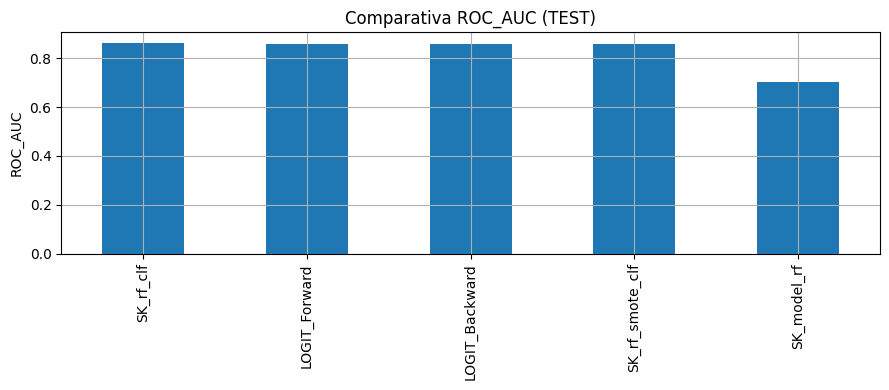

✅ Gráfico AUC guardado: /content/outputs/comparativa_auc.png
Mejor modelo por ROC_AUC: SK_rf_clf


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


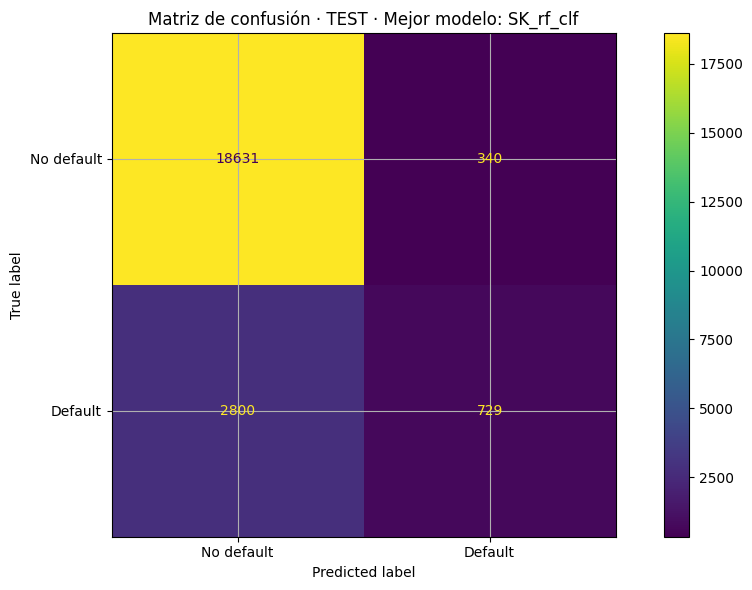

✅ Matriz confusión guardada: /content/outputs/cm_mejor_modelo.png


In [22]:
# PASO 9 · Comparativa final de modelos + exportación + gráficos
# (VERSIÓN FINAL) Incluye:
# (A) detector sklearn SOLO modelos entrenados (evita capturar clases sin fit)
# (B) dummies de EmploymentStatus para evaluación sklearn (evita strings tipo "Employed")
# (C) matriz de confusión del mejor modelo también si es sklearn
# (D) ALINEACIÓN DE COLUMNAS CON feature_names_in_ (arregla "columns are missing: {'EmploymentStatus'}")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# =========================
# 0) Carpeta de salida
# =========================
OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Guardando en:", OUT_DIR)

# =========================
# 1) Funciones auxiliares
# =========================
def resumen_metricas(y_true, y_pred, y_proba):
    roc = np.nan
    if len(np.unique(y_true)) >= 2:
        roc = roc_auc_score(y_true, y_proba)
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC":   roc,
    }

def add_row(metricas_dict, nombre, y_true, y_pred, y_proba, extra=None):
    row = resumen_metricas(y_true, y_pred, y_proba)
    if extra:
        row.update(extra)
    metricas_dict[nombre] = row

def has(name):
    return name in globals()

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

# =========================
# 2) Diccionario de salida
# =========================
metricas = {}
errores = []

# ==========================================================
# 3) Preparar TEST en formato statsmodels (X_test_sm, y_test_sw)
# ==========================================================
def build_test_sm_if_needed():
    if has("X_test_sm") and has("y_test_sw"):
        return globals()["X_test_sm"], globals()["y_test_sw"]

    if not (has("X_test") and has("y_test") and has("feature_cols_step6")):
        return None, None

    Xp = globals()["X_test"].copy()
    yp = pd.to_numeric(globals()["y_test"], errors="coerce")

    bool_cols = Xp.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        Xp[bool_cols] = Xp[bool_cols].astype(int)

    if "EmploymentStatus" in Xp.columns:
        Xp = pd.get_dummies(Xp, columns=["EmploymentStatus"], drop_first=True)

    feature_cols = globals()["feature_cols_step6"]
    for col in feature_cols:
        if col not in Xp.columns:
            Xp[col] = 0
    Xp = Xp[feature_cols].apply(pd.to_numeric, errors="coerce")

    mask = yp.notna() & Xp.notna().all(axis=1)
    Xp = Xp.loc[mask]
    yp = yp.loc[mask].astype(int)

    Xp_sm = sm.add_constant(Xp, has_constant="add").astype(float)
    return Xp_sm, yp

X_test_sm_local, y_test_sw_local = build_test_sm_if_needed()

# ==========================================================
# 4) Evaluación de modelos statsmodels (LOGIT bw/fw + PROBIT)
# ==========================================================
def eval_statsmodels_model(model_name, model_var, cols_var):
    mdl = globals()[model_var]
    cols = globals()[cols_var]

    if X_test_sm_local is None or y_test_sw_local is None:
        raise RuntimeError("No puedo preparar X_test_sm / y_test_sw para evaluar modelos statsmodels.")

    X_eval = X_test_sm_local[cols].astype(float).values
    y_true = y_test_sw_local.values

    y_proba = mdl.predict(X_eval)
    y_pred  = (y_proba >= 0.5).astype(int)

    extra = {}
    if hasattr(mdl, "llf"): extra["LogLik"] = safe_float(mdl.llf)
    if hasattr(mdl, "aic"): extra["AIC"] = safe_float(mdl.aic)
    if hasattr(mdl, "bic"): extra["BIC"] = safe_float(mdl.bic)

    add_row(metricas, model_name, y_true, y_pred, y_proba, extra=extra)

# LOGIT Backward
if has("model_logit_bw") and has("cols_logit_bw"):
    try:
        eval_statsmodels_model("LOGIT_Backward", "model_logit_bw", "cols_logit_bw")
    except Exception as e:
        errores.append(("LOGIT_Backward", repr(e)))

# LOGIT Forward
if has("model_logit_fw") and has("cols_logit_fw"):
    try:
        eval_statsmodels_model("LOGIT_Forward", "model_logit_fw", "cols_logit_fw")
    except Exception as e:
        errores.append(("LOGIT_Forward", repr(e)))

# PROBIT (comparabilidad: columnas del backward)
if has("model_probit") and has("cols_logit_bw"):
    try:
        globals()["cols_probit_use"] = globals()["cols_logit_bw"]
        eval_statsmodels_model("PROBIT", "model_probit", "cols_probit_use")
    except Exception as e:
        errores.append(("PROBIT", repr(e)))

# ==========================================================
# 5) GLM_stepwise "antiguo" si existe (model_glm/cols_finales)
# ==========================================================
if has("model_glm") and has("cols_finales") and has("X_test") and has("y_test") and has("feature_cols_step6"):
    try:
        Xp = globals()["X_test"].copy()
        yt = pd.to_numeric(globals()["y_test"], errors="coerce")

        bool_cols = Xp.select_dtypes(include=["bool"]).columns
        if len(bool_cols) > 0:
            Xp[bool_cols] = Xp[bool_cols].astype(int)

        if "EmploymentStatus" in Xp.columns:
            Xp = pd.get_dummies(Xp, columns=["EmploymentStatus"], drop_first=True)

        feature_cols = globals()["feature_cols_step6"]
        for col in feature_cols:
            if col not in Xp.columns:
                Xp[col] = 0
        Xp = Xp[feature_cols].apply(pd.to_numeric, errors="coerce")

        mask = yt.notna() & Xp.notna().all(axis=1)
        Xp = Xp.loc[mask]
        yt = yt.loc[mask].astype(int)

        Xp_sm = sm.add_constant(Xp, has_constant="add")
        cols_finales = globals()["cols_finales"]
        for col in cols_finales:
            if col not in Xp_sm.columns:
                Xp_sm[col] = 0
        Xp_final = Xp_sm[cols_finales].astype(float)

        mdl = globals()["model_glm"]
        y_proba = mdl.predict(Xp_final.values)
        y_pred  = (y_proba >= 0.5).astype(int)

        extra = {}
        if hasattr(mdl, "llf"): extra["LogLik"] = safe_float(mdl.llf)
        if hasattr(mdl, "aic"): extra["AIC"] = safe_float(mdl.aic)
        if hasattr(mdl, "bic"): extra["BIC"] = safe_float(mdl.bic)

        add_row(metricas, "GLM_stepwise", yt.values, y_pred, y_proba, extra=extra)

    except Exception as e:
        errores.append(("GLM_stepwise", repr(e)))

# ==========================================================
# 6) Modelos sklearn: detección automática (FIX A + FIX B + FIX D)
# ==========================================================
name_patterns = ["knn", "rf", "random", "xgb", "xgboost", "svm", "nb", "naive", "logreg", "lr", "gbm", "gradient", "tree"]
sklearn_models_found = []

for varname, obj in list(globals().items()):
    low = varname.lower()
    # FIX A: solo objetos entrenados (evita capturar clases/constructores)
    is_trained = any(hasattr(obj, att) for att in ["n_features_in_", "classes_", "estimators_"])
    if any(p in low for p in name_patterns) and hasattr(obj, "predict") and is_trained:
        sklearn_models_found.append((varname, obj))

# Evaluación sklearn si hay X_test/y_test
X_eval_base = None
y_test_num = None

if has("X_test") and has("y_test") and len(sklearn_models_found) > 0:
    y_test_num = pd.to_numeric(globals()["y_test"], errors="coerce")
    mask_y = y_test_num.notna()
    y_test_num = y_test_num.loc[mask_y].astype(int)

    X_eval_base = globals()["X_test"].loc[mask_y].copy()

    # bool -> int
    bool_cols = X_eval_base.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X_eval_base[bool_cols] = X_eval_base[bool_cols].astype(int)

    # FIX B: dummies EmploymentStatus
    if "EmploymentStatus" in X_eval_base.columns:
        X_eval_base = pd.get_dummies(X_eval_base, columns=["EmploymentStatus"], drop_first=True)

    # numérico
    X_eval_base = X_eval_base.apply(pd.to_numeric, errors="coerce")

    for varname, mdl in sklearn_models_found:
        try:
            # Copia por modelo (para poder reindexar distinto según feature_names_in_)
            X_eval = X_eval_base.copy()
            y_eval = y_test_num.copy()

            # drop NaN filas (para sklearn)
            maskX = X_eval.notna().all(axis=1)
            X_eval = X_eval.loc[maskX]
            y_eval = y_eval.loc[maskX]

            # FIX D: alinear con columnas de entrenamiento si están disponibles
            if hasattr(mdl, "feature_names_in_"):
                train_cols = list(mdl.feature_names_in_)
                X_eval = X_eval.reindex(columns=train_cols, fill_value=0)

            # Probabilidades / scores
            if hasattr(mdl, "predict_proba"):
                y_proba = mdl.predict_proba(X_eval)[:, 1]
            elif hasattr(mdl, "decision_function"):
                scores = mdl.decision_function(X_eval)
                y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
            else:
                y_pred_tmp = mdl.predict(X_eval)
                y_proba = np.array(y_pred_tmp, dtype=float)

            y_pred = mdl.predict(X_eval)
            add_row(metricas, f"SK_{varname}", y_eval.values, y_pred, y_proba)

        except Exception as e:
            errores.append((f"SK_{varname}", repr(e)))

# ==========================================================
# 7) Si sigue vacío, diagnóstico
# ==========================================================
if len(metricas) == 0:
    print("\n❌ No se pudo evaluar ningún modelo. Diagnóstico rápido:")
    print("¿Existe model_logit_bw?", has("model_logit_bw"))
    print("¿Existe model_logit_fw?", has("model_logit_fw"))
    print("¿Existe model_probit?", has("model_probit"))
    print("¿Existe model_glm?", has("model_glm"))
    print("¿Existe X_test_sm/y_test_sw?", has("X_test_sm"), has("y_test_sw"))
    print("¿Existe feature_cols_step6?", has("feature_cols_step6"))
    print("\nErrores capturados:")
    for e in errores[:30]:
        print(" -", e[0], "->", e[1])

else:
    # ==========================================================
    # 8) Tabla final + exportación
    # ==========================================================
    df_metricas_final = pd.DataFrame(metricas).T
    col_order = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "LogLik", "AIC", "BIC"]
    df_metricas_final = df_metricas_final[[c for c in col_order if c in df_metricas_final.columns]]

    df_metricas_final = df_metricas_final.sort_values("ROC_AUC", ascending=False)
    display(df_metricas_final)

    csv_path = os.path.join(OUT_DIR, "comparativa_modelos.csv")
    df_metricas_final.to_csv(csv_path, index=True)
    print("✅ CSV guardado:", csv_path)

    # ==========================================================
    # 9) Gráfico AUC
    # ==========================================================
    if "ROC_AUC" in df_metricas_final.columns:
        plt.figure(figsize=(9, 4))
        df_metricas_final["ROC_AUC"].plot(kind="bar")
        plt.title("Comparativa ROC_AUC (TEST)")
        plt.ylabel("ROC_AUC")
        plt.tight_layout()
        auc_path = os.path.join(OUT_DIR, "comparativa_auc.png")
        plt.savefig(auc_path, dpi=200)
        plt.show()
        print("✅ Gráfico AUC guardado:", auc_path)

    # ==========================================================
    # 10) Matriz de confusión del mejor modelo (FIX C)
    # ==========================================================
    best_model = df_metricas_final["ROC_AUC"].idxmax() if "ROC_AUC" in df_metricas_final.columns else None
    print("Mejor modelo por ROC_AUC:", best_model)

    # Guardamos el mismo nombre que tú viste en output
    cm_path = os.path.join(OUT_DIR, "cm_mejor_modelo.png")

    try:
        # Caso statsmodels
        if best_model == "LOGIT_Backward":
            mdl, cols = globals()["model_logit_bw"], globals()["cols_logit_bw"]
            y_proba = mdl.predict(X_test_sm_local[cols].astype(float).values)
            y_pred  = (y_proba >= 0.5).astype(int)
            cm = confusion_matrix(y_test_sw_local.values, y_pred)
            ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d")
            plt.title("Matriz de confusión · TEST · LOGIT_Backward")
            plt.tight_layout()
            plt.savefig(cm_path, dpi=200)
            plt.show()
            print("✅ Matriz confusión guardada:", cm_path)

        elif best_model == "LOGIT_Forward":
            mdl, cols = globals()["model_logit_fw"], globals()["cols_logit_fw"]
            y_proba = mdl.predict(X_test_sm_local[cols].astype(float).values)
            y_pred  = (y_proba >= 0.5).astype(int)
            cm = confusion_matrix(y_test_sw_local.values, y_pred)
            ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d")
            plt.title("Matriz de confusión · TEST · LOGIT_Forward")
            plt.tight_layout()
            plt.savefig(cm_path, dpi=200)
            plt.show()
            print("✅ Matriz confusión guardada:", cm_path)

        elif best_model == "PROBIT":
            mdl, cols = globals()["model_probit"], globals()["cols_logit_bw"]
            y_proba = mdl.predict(X_test_sm_local[cols].astype(float).values)
            y_pred  = (y_proba >= 0.5).astype(int)
            cm = confusion_matrix(y_test_sw_local.values, y_pred)
            ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d")
            plt.title("Matriz de confusión · TEST · PROBIT")
            plt.tight_layout()
            plt.savefig(cm_path, dpi=200)
            plt.show()
            print("✅ Matriz confusión guardada:", cm_path)

        # Caso sklearn (FIX C)
        elif best_model and best_model.startswith("SK_") and has("X_test") and has("y_test"):
            # best_model = "SK_<varname>"
            varname = best_model.replace("SK_", "")
            if varname in globals():
                mdl = globals()[varname]

                # reconstruimos X para sklearn igual que en evaluación
                y_test_num2 = pd.to_numeric(globals()["y_test"], errors="coerce")
                mask_y2 = y_test_num2.notna()
                y_test_num2 = y_test_num2.loc[mask_y2].astype(int)

                X_eval2 = globals()["X_test"].loc[mask_y2].copy()

                bool_cols2 = X_eval2.select_dtypes(include=["bool"]).columns
                if len(bool_cols2) > 0:
                    X_eval2[bool_cols2] = X_eval2[bool_cols2].astype(int)

                if "EmploymentStatus" in X_eval2.columns:
                    X_eval2 = pd.get_dummies(X_eval2, columns=["EmploymentStatus"], drop_first=True)

                X_eval2 = X_eval2.apply(pd.to_numeric, errors="coerce")

                maskX2 = X_eval2.notna().all(axis=1)
                X_eval2 = X_eval2.loc[maskX2]
                y_eval2 = y_test_num2.loc[maskX2]

                # alinear columnas si aplica (FIX D también aquí)
                if hasattr(mdl, "feature_names_in_"):
                    X_eval2 = X_eval2.reindex(columns=list(mdl.feature_names_in_), fill_value=0)

                y_pred_best = mdl.predict(X_eval2)

                cm = confusion_matrix(y_eval2.values, y_pred_best)
                ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d")
                plt.title(f"Matriz de confusión · TEST · Mejor modelo: {best_model}")
                plt.tight_layout()
                plt.savefig(cm_path, dpi=200)
                plt.show()
                print("✅ Matriz confusión guardada:", cm_path)

    except Exception as e:
        print("⚠️ No pude generar matriz de confusión del mejor modelo:", repr(e))

    # ==========================================================
    # 11) Errores no críticos (para depurar)
    # ==========================================================
    if len(errores) > 0:
        print("\n⚠️ Modelos detectados pero fallaron al evaluar (no crítico):")
        for e in errores[:30]:
            print(" -", e[0], "->", e[1])


In [23]:
# ============================================================
# EXPORTACIÓN COMPLETA DE RESULTADOS PARA EL TFG
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1) Guardar tabla resumen métricas
# ------------------------------------------------------------
df_report.to_csv(f"{OUTPUT_DIR}/comparativa_modelos_completa.csv", index=False)

# ------------------------------------------------------------
# 2) Guardar coeficientes de cada modelo
# ------------------------------------------------------------
def save_coef_table(model, cols, name):
    df_coef = pd.DataFrame({
        "variable": cols,
        "coef": model.params,
        "pvalue": model.pvalues
    }).sort_values("pvalue")
    df_coef.to_csv(f"{OUTPUT_DIR}/coeficientes_{name}.csv", index=False)

save_coef_table(model_logit_bw, cols_logit_bw, "logit_backward")
save_coef_table(model_logit_fw, cols_logit_fw, "logit_forward")
save_coef_table(model_probit_bw, cols_probit_bw, "probit_backward")
save_coef_table(model_probit_fw, cols_probit_fw, "probit_forward")

# ------------------------------------------------------------
# 3) Guardar ROC individuales en alta calidad
# ------------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score

def save_roc_plot(name, mdl, cols):
    p_tr = get_pred_proba(mdl, X_train_sm, cols)
    p_te = get_pred_proba(mdl, X_test_sm, cols)

    fpr_tr, tpr_tr, _ = roc_curve(y_train_sw, p_tr)
    fpr_te, tpr_te, _ = roc_curve(y_test_sw, p_te)

    auc_tr = roc_auc_score(y_train_sw, p_tr)
    auc_te = roc_auc_score(y_test_sw, p_te)

    plt.figure(figsize=(6,5))
    plt.plot(fpr_tr, tpr_tr, label=f"TRAIN (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"TEST (AUC={auc_te:.3f})")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/roc_{name}.png", dpi=300)
    plt.close()

MODELS = [
    ("logit_backward",  model_logit_bw,  cols_logit_bw),
    ("logit_forward",   model_logit_fw,  cols_logit_fw),
    ("probit_backward", model_probit_bw, cols_probit_bw),
    ("probit_forward",  model_probit_fw, cols_probit_fw),
]

for name, mdl, cols in MODELS:
    save_roc_plot(name, mdl, cols)

# ------------------------------------------------------------
# 4) Guardar matrices de confusión (TEST)
# ------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def save_cm(name, mdl, cols):
    p_te = get_pred_proba(mdl, X_test_sm, cols)
    yhat_te = (p_te >= 0.5).astype(int)

    cm = confusion_matrix(y_test_sw, yhat_te)

    disp = ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"])
    disp.plot(values_format="d")
    plt.title(f"Matriz Confusión TEST - {name}")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/cm_{name}.png", dpi=300)
    plt.close()

for name, mdl, cols in MODELS:
    save_cm(name, mdl, cols)

# ------------------------------------------------------------
# 5) Guardar predicciones TRAIN y TEST
# ------------------------------------------------------------
def save_predictions(name, mdl, cols):
    df_train_pred = pd.DataFrame({
        "y_real": y_train_sw,
        "prob_default": get_pred_proba(mdl, X_train_sm, cols)
    })
    df_train_pred.to_csv(f"{OUTPUT_DIR}/pred_train_{name}.csv", index=False)

    df_test_pred = pd.DataFrame({
        "y_real": y_test_sw,
        "prob_default": get_pred_proba(mdl, X_test_sm, cols)
    })
    df_test_pred.to_csv(f"{OUTPUT_DIR}/pred_test_{name}.csv", index=False)

for name, mdl, cols in MODELS:
    save_predictions(name, mdl, cols)

print("✅ EXPORTACIÓN COMPLETA FINALIZADA")
print(f"Archivos guardados en carpeta: {OUTPUT_DIR}")


✅ EXPORTACIÓN COMPLETA FINALIZADA
Archivos guardados en carpeta: outputs


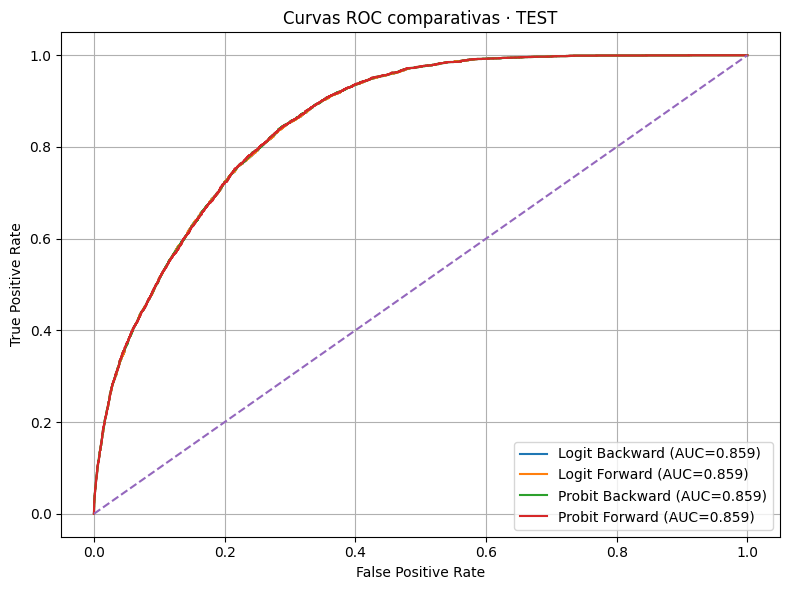

✅ ROC conjunta guardada en outputs/roc_4_modelos_test.png


In [24]:
# ============================================================
# ROC conjunta · 4 modelos en una sola figura (TEST)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_pred_proba(model, X_sm, cols):
    return model.predict(X_sm[cols].astype(float).values)

# Definimos los 4 modelos
MODELS_ROC = [
    ("Logit Backward",  model_logit_bw,   cols_logit_bw),
    ("Logit Forward",   model_logit_fw,   cols_logit_fw),
    ("Probit Backward", model_probit_bw,  cols_probit_bw),
    ("Probit Forward",  model_probit_fw,  cols_probit_fw),
]

plt.figure(figsize=(8,6))

for name, mdl, cols in MODELS_ROC:
    p_test = get_pred_proba(mdl, X_test_sm, cols)
    fpr, tpr, _ = roc_curve(y_test_sw, p_test)
    auc = roc_auc_score(y_test_sw, p_test)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# Línea diagonal referencia
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC comparativas · TEST")
plt.legend()
plt.tight_layout()

# Guardar en outputs
plt.savefig(f"{OUTPUT_DIR}/roc_4_modelos_test.png", dpi=300)
plt.show()
plt.close()

print("✅ ROC conjunta guardada en outputs/roc_4_modelos_test.png")


In [25]:
p1 = get_pred_proba(model_logit_bw, X_test_sm, cols_logit_bw)
p2 = get_pred_proba(model_probit_bw, X_test_sm, cols_probit_bw)

np.corrcoef(p1, p2)[0,1]


np.float64(0.9989825101268426)

In [26]:
# ============================================================
# EXPORTACIÓN MASIVA EXTRA PARA TFG
# - Heatmaps de correlación (post-eliminación y, si existe, pre)
# - Gráfico comparativo AUC en una sola figura
# - Importancia de variables (coef/|z|) para Logit/Probit
# - Gráficos bidimensionales (score vs variable con media real)
# - PDF con distribución de TODAS las numéricas del Paso 4
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (opcional pero recomendado para heatmaps)
import seaborn as sns

from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import roc_curve, roc_auc_score

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Helper: detectar df "Paso 4" para distribuciones
# Priorizamos: X (post step 4/4.5), si no, X_train_sw, si no X_train
# ------------------------------------------------------------
def _pick_step4_df():
    if "X" in globals() and isinstance(globals()["X"], pd.DataFrame):
        return globals()["X"]
    if "X_train_sw" in globals() and isinstance(globals()["X_train_sw"], pd.DataFrame):
        return globals()["X_train_sw"]
    if "X_train" in globals() and isinstance(globals()["X_train"], pd.DataFrame):
        return globals()["X_train"]
    return None

df_step4 = _pick_step4_df()


# ============================================================
# 1) HEATMAPS DE CORRELACIÓN
# ============================================================
def save_corr_heatmap(df, name, title=None, threshold_pairs=None):
    """
    Guarda heatmap triangular de correlación numérica.
    Si threshold_pairs se indica, también guarda CSV de pares |r|>=threshold_pairs.
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) < 2:
        print(f"⚠️ [{name}] No hay suficientes columnas numéricas para correlación.")
        return

    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    plt.figure(figsize=(16, 12))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(title or f"Matriz de correlación · {name}")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/heatmap_corr_{name}.png", dpi=300)
    plt.close()

    # opcional: exportar pares aún altos
    if threshold_pairs is not None:
        corr_abs = corr.abs()
        pairs = corr_abs.where(mask).stack().reset_index()
        pairs.columns = ["var1", "var2", "corr_abs"]
        pairs = pairs[pairs["corr_abs"] >= threshold_pairs].sort_values("corr_abs", ascending=False)
        pairs.to_csv(f"{OUTPUT_DIR}/corr_pairs_{name}_absge_{threshold_pairs}.csv", index=False)


# (A) Correlación POST eliminación: normalmente es X (ya reducido por paso 4.5)
if df_step4 is not None:
    save_corr_heatmap(
        df_step4,
        name="post_eliminacion",
        title="Matriz de correlación (post eliminación de variables correlacionadas)",
        threshold_pairs=0.7
    )
else:
    print("⚠️ No se encontró un dataframe para correlación post-eliminación.")

# (B) Correlación PRE eliminación (si la tienes en alguna variable)
# Si en tu notebook guardaste el X antes de eliminar, por ejemplo X_pre_corr o X_before_corr
pre_candidates = ["X_pre_corr", "X_before_corr", "X_model_limpio", "df_model_limpio"]
for cand in pre_candidates:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame):
        save_corr_heatmap(
            globals()[cand],
            name=f"pre_eliminacion_{cand}",
            title=f"Matriz de correlación (pre eliminación) · {cand}",
            threshold_pairs=0.7
        )
        break


# ============================================================
# 2) GRÁFICO COMPARATIVO AUC (una sola figura)
#    - usa df_report (creado en Paso 7)
# ============================================================
if "df_report" in globals() and isinstance(df_report, pd.DataFrame):
    # aseguramos que exista el formato esperado
    auc_df = df_report.copy()

    # pivot: filas modelo, cols split, valores roc_auc
    try:
        auc_pivot = auc_df.pivot_table(index="Modelo", columns="Split", values="ROC_AUC", aggfunc="mean")
        plt.figure(figsize=(8, 5))
        auc_pivot.plot(kind="bar")
        plt.title("Comparativa ROC AUC · TRAIN vs TEST")
        plt.xlabel("Modelo")
        plt.ylabel("ROC AUC")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/comparativa_auc_una_figura.png", dpi=300)
        plt.close()

        # guardar también tabla
        auc_pivot.to_csv(f"{OUTPUT_DIR}/comparativa_auc_una_figura.csv")
    except Exception as e:
        print("⚠️ No se pudo generar comparativa AUC en una figura:", str(e))
else:
    print("⚠️ df_report no existe. No se exporta comparativa AUC.")


# ============================================================
# 3) IMPORTANCIA DE VARIABLES (para Logit/Probit)
#    - usaremos |z| (tvalues) como importancia (robusto y estándar)
#    - guardamos CSV + barplot top 20
# ============================================================
def save_variable_importance_statsmodels(model, cols, name, top_n=20):
    # statsmodels devuelve params y tvalues en el orden del modelo
    df_imp = pd.DataFrame({
        "variable": cols,
        "coef": model.params,
        "z_value": model.tvalues,
        "pvalue": model.pvalues
    })
    df_imp["importance_abs_z"] = df_imp["z_value"].abs()

    # quitamos const para ranking
    df_rank = df_imp[df_imp["variable"] != "const"].sort_values("importance_abs_z", ascending=False)

    df_imp.to_csv(f"{OUTPUT_DIR}/importancia_variables_{name}_full.csv", index=False)
    df_rank.head(top_n).to_csv(f"{OUTPUT_DIR}/importancia_variables_{name}_top{top_n}.csv", index=False)

    # plot top N
    top = df_rank.head(top_n).iloc[::-1]  # para que el mayor quede arriba al final
    plt.figure(figsize=(8, 7))
    plt.barh(top["variable"], top["importance_abs_z"])
    plt.title(f"Importancia de variables (|z|) · {name} · Top {top_n}")
    plt.xlabel("|z|")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/importancia_variables_{name}_top{top_n}.png", dpi=300)
    plt.close()

# MODELS debería existir del Paso 7; si no, lo reconstruimos
if "MODELS" not in globals():
    MODELS = [
        ("LOGIT_Backward",  model_logit_bw,   cols_logit_bw),
        ("LOGIT_Forward",   model_logit_fw,   cols_logit_fw),
        ("PROBIT_Backward", model_probit_bw,  cols_probit_bw),
        ("PROBIT_Forward",  model_probit_fw,  cols_probit_fw),
    ]

for name, mdl, cols in MODELS:
    safe_name = name.lower()
    try:
        save_variable_importance_statsmodels(mdl, cols, safe_name, top_n=20)
    except Exception as e:
        print(f"⚠️ No se pudo exportar importancias para {name}: {e}")


# ============================================================
# 4) GRÁFICOS BIDIMENSIONALES (score vs variable) + tabla por bins
#    Guardamos: PNG + CSV (agg)
#    Usa tu idea: groupby/bins para evitar solape.
# ============================================================
def grouped_curve_table(df, x_col, p_col, y_col="y_real", n_bins=20):
    work = df[[x_col, p_col, y_col]].copy()
    work = work.replace([np.inf, -np.inf], np.nan).dropna()

    uniq = work[x_col].nunique()
    bins = int(min(n_bins, max(3, uniq)))

    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")

    agg = (
        work.groupby("bin", observed=True)
            .agg(
                x_mean=(x_col, "mean"),
                p_mean=(p_col, "mean"),
                y_mean=(y_col, "mean"),
                n=(y_col, "size")
            )
            .reset_index(drop=True)
            .sort_values("x_mean")
    )
    return agg

def save_bivariate_plot_and_table(df, x_col, p_col, split_name, model_name, n_bins=20):
    agg = grouped_curve_table(df, x_col, p_col, y_col="y_real", n_bins=n_bins)

    # guardar tabla
    safe = lambda s: s.replace(" ", "_").replace("/", "_")
    fname_base = f"bivar_{safe(model_name)}_{safe(split_name)}_X_{safe(x_col)}"
    agg.to_csv(f"{OUTPUT_DIR}/{fname_base}.csv", index=False)

    # plot
    plt.figure(figsize=(9, 6))
    plt.plot(agg["x_mean"], agg["p_mean"], marker="o", label="Score medio (predicho)")
    plt.plot(agg["x_mean"], agg["y_mean"], marker="o", label="Default real medio")
    plt.title(f"{model_name} · {split_name}\nScore vs Real (agrupado) · X={x_col}")
    plt.xlabel(x_col)
    plt.ylabel("Probabilidad / Tasa de default")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{fname_base}.png", dpi=300)
    plt.close()

# Construimos dataframes de scores (si no existen ya)
def get_pred_proba(model, X_sm, cols):
    return model.predict(X_sm[cols].astype(float).values)

# TRAIN scores df
df_train_scores = X_train_sm.copy()
df_train_scores["y_real"] = y_train_sw.values
for name, mdl, cols in MODELS:
    df_train_scores[f"p_{name}"] = get_pred_proba(mdl, X_train_sm, cols)

# TEST scores df (si no existe, lo creamos)
if "X_test_sm" in globals() and "y_test_sw" in globals():
    df_test_scores = X_test_sm.copy()
    df_test_scores["y_real"] = y_test_sw.values
    for name, mdl, cols in MODELS:
        df_test_scores[f"p_{name}"] = get_pred_proba(mdl, X_test_sm, cols)
else:
    df_test_scores = None
    print("⚠️ X_test_sm / y_test_sw no existen. No se exportan bivariados de TEST.")

# Variables recomendadas (usa solo las que existan)
candidate_features = [
    "BorrowerAPR",
    "CreditScoreRangeLower",
    "CreditScoreRangeUpper",
    "log_LoanOriginalAmount",
    "BankcardUtilization",
    "AvailableBankcardCredit",
    "AmountDelinquent"
]

# Exportar bivariados (TRAIN + TEST)
for x_col in candidate_features:
    if x_col not in df_train_scores.columns:
        continue

    for name, _, _ in MODELS:
        pcol = f"p_{name}"
        try:
            save_bivariate_plot_and_table(df_train_scores, x_col, pcol, "TRAIN", name, n_bins=20)
        except Exception as e:
            print(f"⚠️ No se pudo exportar bivariado TRAIN {name} X={x_col}: {e}")

        if df_test_scores is not None and x_col in df_test_scores.columns:
            try:
                save_bivariate_plot_and_table(df_test_scores, x_col, pcol, "TEST", name, n_bins=20)
            except Exception as e:
                print(f"⚠️ No se pudo exportar bivariado TEST {name} X={x_col}: {e}")


# ============================================================
# 5) PDF · Distribución de variables numéricas del Paso 4
#    Un histograma por variable (auto)
# ============================================================
def export_numeric_distributions_pdf(df, pdf_path, bins=30):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        print("⚠️ No hay columnas numéricas para exportar distribuciones.")
        return

    with PdfPages(pdf_path) as pdf:
        for col in num_cols:
            s = pd.to_numeric(df[col], errors="coerce").dropna()
            if s.empty:
                continue

            plt.figure(figsize=(8, 5))
            plt.hist(s.values, bins=bins)
            plt.title(f"Distribución: {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            pdf.savefig()
            plt.close()

    print(f"✅ PDF guardado: {pdf_path}")

if df_step4 is not None:
    export_numeric_distributions_pdf(df_step4, f"{OUTPUT_DIR}/distribuciones_numericas_paso4.pdf", bins=30)
else:
    print("⚠️ No se encontró df_step4 para generar el PDF de distribuciones.")


print("✅ EXPORTACIÓN MASIVA (extra) FINALIZADA")
print(f"Revisa la carpeta: {OUTPUT_DIR}")


✅ PDF guardado: outputs/distribuciones_numericas_paso4.pdf
✅ EXPORTACIÓN MASIVA (extra) FINALIZADA
Revisa la carpeta: outputs


<Figure size 800x500 with 0 Axes>

In [27]:
import shutil
from google.colab import files

# Crear zip
shutil.make_archive("outputs_completo", "zip", "outputs")

# Descargar
files.download("outputs_completo.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>